# 🏥 Track IV — Human Health / Digital Health Intelligence
## Vector-Borne Disease Prediction: Feature Significance Analysis
**FIT Competition 2026 | Digital Impact for Humanitarian Response and Global Well-Being**

---
### Objective
Identify which clinical symptoms and laboratory findings significantly influence the diagnosis of each vector-borne disease (Malaria, Dengue, Yellow Fever, Typhoid Fever) using appropriate statistical tests based on data type.


## 1. Setup & Library Import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0',
    'grid.color': '#334155',
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
DISEASE_COLORS = {
    'Malaria':      '#3b82f6',
    'Dengue':       '#10b981',
    'Yellow_Fever': '#f59e0b',
    'Typhoid':      '#a855f7',
    'Others':       '#ef4444'
}
print("Libraries loaded.")


Libraries loaded.


## 2. Data Loading & Initial Inspection

In [6]:
df = pd.read_csv('data.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn overview:")
print(df.dtypes.value_counts())
df.head(3)


Dataset shape: (300, 109)

Column overview:
str        97
float64    12
Name: count, dtype: int64


,Centre de santé,Genre (Gender),Âge (Age),Poids (Weight),Circonference du bras (Mua circumference),"Haute température.(temperature, Hyperpyrexia)",Fièvre depuis 48 heures(Fever 48 hrs),Fièvre au cours des 7 derniers jours (Fever in the last 7 days),Type de fièvre (Type of Fever),Perte de poids (Loss of Weight),...,Maladies diagnostiquées/Paludisme (Malaria),Maladies diagnostiquées/Dengue,Maladies diagnostiquées/Chikunguya,Maladies diagnostiquées/Fièvre jaune (yellow fever),Maladies diagnostiquées/Fièvre Typhoïde (Thyphoid fever),Maladies diagnostiquées/Zika,Maladies diagnostiquées/Autres maladies diagnostiqué (Others diseases),Maladies diagnostiquées/Option 8,Autres maladies présentées par le patient,_uuid
0,CMA de DO,Femme,18,55.0,NaN,OUI,OUI,OUI,Récurrente,NON,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,df22d899-23a3-4c49-8059-6208c130f57d
1,CMA de DO,Homme,26,120.0,NaN,OUI,OUI,OUI,Récurrente,NON,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,4a7ef2f3-4ff0-4215-8cb5-20ba8c8d4355
2,CMA de DO,Homme,25,63.0,NaN,OUI,OUI,OUI,Récurrente,NON,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,104f6bc8-f39a-482b-b680-7ac1f8cccc86


In [7]:
# Target disease columns
target_map = {
    'Malaria':      'Maladies diagnostiquées/Paludisme (Malaria)',
    'Dengue':       'Maladies diagnostiquées/Dengue',
    'Yellow_Fever': 'Maladies diagnostiquées/Fièvre jaune (yellow fever)',
    'Typhoid':      'Maladies diagnostiquées/Fièvre Typhoïde (Thyphoid fever)',
    'Others':       'Maladies diagnostiquées/Autres maladies diagnostiqué (Others diseases)'
}

print("Disease label distribution:")
for name, col in target_map.items():
    counts = df[col].value_counts()
    pos = counts.get(1.0, 0)
    total = counts.sum()
    print(f"  {name:15s}: {pos:3d}/{total} ({100*pos/total:.1f}%)")


Disease label distribution:
  Malaria        : 270/299 (90.3%)
  Dengue         :  56/299 (18.7%)
  Yellow_Fever   :  12/299 (4.0%)
  Typhoid        :  29/299 (9.7%)
  Others         :  99/299 (33.1%)


## 3. Data Preprocessing
### 3.1 Column Renaming (French -> English)

In [8]:
rename_map = {
    'Genre (Gender)': 'Gender',
    'Âge (Age)': 'Age',
    'Poids (Weight)': 'Weight_kg',
    'Circonference du bras (Mua circumference)': 'Arm_Circumference_cm',
    'Haute température.(temperature, Hyperpyrexia)': 'High_Temperature_C',
    'Fièvre depuis 48 heures(Fever 48 hrs)': 'Fever_48h',
    'Fièvre au cours des 7 derniers jours (Fever in the last 7 days)': 'Fever_7days',
    'Type de fièvre (Type of Fever)': 'Fever_Type',
    'Perte de poids (Loss of Weight)': 'Weight_Loss',
    'Maux de tête (headache)': 'Headache',
    'Nausée (Nausea)': 'Nausea',
    'Vomissement (Vomiting)': 'Vomiting',
    'Douleur articulaire (Joint pain)': 'Joint_Pain',
    'Gonflement des articulations (Joint Swelling)': 'Joint_Swelling',
    'Douleur musculaire ( Muscle pain)': 'Muscle_Pain',
    'Douleur Thoracique (Chaist pain)': 'Chest_Pain',
    'Mal de dos / Douleur rachidienne ( Back pain / Rachiodynia)': 'Back_Pain',
    'Troubles de la conscience (Consciousness trouble)': 'Consciousness_Trouble',
    'Perte dappétit ou Anorexie (Loss of appetite or Anorexia)': 'Loss_of_Appetite',
    'Éruptions cutanées ou Exanthème (Skin rash or Exanthema)': 'Skin_Rash',
    'Éruption morbilliforme (Morbilliform rash)': 'Morbilliform_Rash',
    'Saignement/ Manifestations hémorragiques (Bleeding)': 'Bleeding',
    'Rhinorrhée (Rhinorrhea)': 'Rhinorrhea',
    'Somnolence ou léthargie  (Drowsiness or lethargy)': 'Drowsiness',
    'Vertige (Dizzy)': 'Dizziness',
    'Inflammation de conjonctivite': 'Conjunctivitis',
    'Douleur abdominale (stomac pain)': 'Abdominal_Pain',
    'Distension abdominale (Ventre gonflé) (Abdominal Distension (Swelling Stomach)/ Ascites)': 'Abdominal_Distension',
    'Mal de gorge (throat pain)': 'Throat_Pain',
    'Toux (Cough)': 'Cough',
    'Diarrhée  (Diarrhea)': 'Diarrhea',
    ' Douleur rétro-orbitrale (Retro-orbital pain)': 'Retro_Orbital_Pain',
    'Céphalée (Headache)': 'Headache_2',
    'Sensation de frissons ou de froid (Shiver or cold sensation)': 'Chills',
    'Mictions fréquentes.(Frequent Urination)': 'Frequent_Urination_1',
    'Constipation': 'Constipation',
    'Oligurie (Oliguria)': 'Oliguria',
    'Mictions fréquentes. (Frequent Urination)': 'Frequent_Urination_2',
    'Prostration': 'Prostration',
    'Ictère (Icterus)': 'Jaundice',
    'Epistaxis ((Bleeding nose)': 'Nosebleed',
    'Convulsions généralisées ou focales (Generalised or focal convulsion)': 'Convulsions',
    'Convulsions multiples (Multiple convulsions)': 'Multiple_Convulsions',
    'Délire ': 'Delirium_1',
    'Confusion/ niveau de conscience altéré (impaired level of consciousness)': 'Impaired_Consciousness',
    'Rougeur faciale (Facial flushing)': 'Facial_Flushing',
    'Gonflement du visage (Facial Swelling)': 'Facial_Swelling',
    'Sudation excessive (Profuse sweating)': 'Profuse_Sweating',
    'Délire /Discours irrationnel (Delirium/ Irrational Talking)': 'Delirium_Irrational',
    'Hémoglobinurie (Hemoglobinuria)': 'Hemoglobinuria',
    'Goût amer dans la gorge (Bitter taste in your Throat)': 'Bitter_Taste',
    'Test de garrot positif (Positive tourniquet test)': 'Tourniquet_Test',
    'Raideur (Stiffness)': 'Stiffness',
    'Détresse respiratoire (Respiratory distress)': 'Respiratory_Distress',
    'Choc septique (Shock)': 'Septic_Shock_1',
    'Hépatomégalie (Hepatomegaly)': 'Hepatomegaly',
    'Insuffisance cardiaque  ou Myocardite(Heart failure or Myocarditis)': 'Heart_Failure',
    'Accumulation de liquide et détresse respiratoire (Accumulation of fluid and respiratory distress)': 'Fluid_Distress',
    'Splénomégalie modérée': 'Splenomegaly',
    'Choc septique (Septicemia)': 'Septicemia',
    'Syndrome dicterus subaigu (Sub-icterus)': 'Sub_Icterus',
    'Lymphadénopathie / Lymphadenopa thy': 'Lymphadenopathy',
    'Température axillaire (médiane IQR) (°C) /Axillary temperature (median IQR) (°C)': 'Axillary_Temp_C',
    'Fréquence respiratoire (médiane IQR) / Respiratory rate (median breaths/min IQR)': 'Respiratory_Rate',
    'Fréquence du pouls (battements/m in ± SD)./ Pulse rate (mean beats/min ± SD) - Shock ou Myocarditis': 'Pulse_Rate',
    'Pression artérielle (moyenne mmHg ± SD). / Arterial blood pressure (mean mmHg ± SD)': 'Blood_Pressure',
    'Temps de remplissage capillaire (médiane secs IQR). / Capillary refill time (median secs IQR)': 'Capillary_Refill',
    'Test TDR': 'RDT_Test',
    'Goutte épaisse ': 'Thick_Blood_Smear',
    ' Hémoconcentration': 'Hemoconcentration',
    'Pâleur cutanéo muqueuse ou Anémie (Mucosal skin pallor or Anemia)': 'Pallor_Anemia',
    'Hypoglycémie (Hypoglycemia)': 'Hypoglycemia',
    'Hematocrite (Hematrocrit)': 'Hematocrit',
    'Transaminases (Transaminases)': 'Transaminases',
    'Thrombocytopénie(Thrombocytopenia)': 'Thrombocytopenia',
    'Lymphocytopénie (Lymphocytopenia)': 'Lymphocytopenia',
    'Lymphocytes ': 'Lymphocytes',
    'Neutropénie (Neutropenia)': 'Neutropenia',
    'Nombre de globules blancs (cellules/ML) / White blood cell count / WBC count (cells/ML)': 'WBC_Count',
    'Numération plaquettaire Platelet count': 'Platelet_Count',
    'Neutrophiles / Neutrophils': 'Neutrophils',
    'CRP>50 /CRP 10-50': 'CRP',
    'Créatinine élevée / Elevated Creatinine': 'Elevated_Creatinine',
    'ALAT / ASAT élevés. / Elevated ALAT / Elevated ASAT': 'Elevated_ALAT_ASAT',
    'Diabète ': 'Diabetes',
    'Hypertension artérielle': 'Hypertension',
    'Drépanocytose': 'Sickle_Cell',
    'Maladie rhumatismale': 'Rheumatic_Disease',
    'Maladie auto immune': 'Autoimmune_Disease',
    'Arthrose': 'Osteoarthritis',
    'Allergies': 'Allergies',
    'Cancer': 'Cancer',
    'Asthme (Astma)': 'Asthma',
    'Carences en leucocytes (Leucopenia)': 'Leukopenia',
    'Pneumonie (Pneumonia)': 'Pneumonia',
    'Maladies diagnostiquées/Paludisme (Malaria)': 'Label_Malaria',
    'Maladies diagnostiquées/Dengue': 'Label_Dengue',
    'Maladies diagnostiquées/Chikunguya': 'Label_Chikungunya',
    'Maladies diagnostiquées/Fièvre jaune (yellow fever)': 'Label_YellowFever',
    'Maladies diagnostiquées/Fièvre Typhoïde (Thyphoid fever)': 'Label_Typhoid',
    'Maladies diagnostiquées/Zika': 'Label_Zika',
    'Maladies diagnostiquées/Autres maladies diagnostiqué (Others diseases)': 'Label_Others',
    'Maladies diagnostiquées/Option 8': 'Label_Option8',
}

df.rename(columns=rename_map, inplace=True)
print(f"Renamed {len(rename_map)} columns")
df.head(2)


Renamed 103 columns


,Centre de santé,Gender,Age,Weight_kg,Arm_Circumference_cm,High_Temperature_C,Fever_48h,Fever_7days,Fever_Type,Weight_Loss,...,Label_Malaria,Label_Dengue,Label_Chikungunya,Label_YellowFever,Label_Typhoid,Label_Zika,Label_Others,Label_Option8,Autres maladies présentées par le patient,_uuid
0,CMA de DO,Femme,18,55.0,NaN,OUI,OUI,OUI,Récurrente,NON,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,df22d899-23a3-4c49-8059-6208c130f57d
1,CMA de DO,Homme,26,120.0,NaN,OUI,OUI,OUI,Récurrente,NON,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,4a7ef2f3-4ff0-4215-8cb5-20ba8c8d4355


### 3.2 Type Conversion & Feature Categorization

In [9]:
#Load Data Again for Cleaning
df = pd.read_csv('data.csv', sep=';')
df.rename(columns=rename_map, inplace=True)

#Parsing Blood Pressure into Systolic and Diastolic (Handling both '/' and '|' as separators)
if 'Blood_Pressure' in df.columns:
    bp_clean = df['Blood_Pressure'].astype(str).str.replace('|', '/', regex=False).str.strip()
    df['Blood_Pressure_Systolic'] = bp_clean.apply(lambda x: x.split('/')[0] if isinstance(x, str) and '/' in x else x)
    df['Blood_Pressure_Diastolic'] = bp_clean.apply(lambda x: x.split('/')[1] if isinstance(x, str) and '/' in x else np.nan)
    # Turn into numeric, coercing errors to NaN
    df['Blood_Pressure_Systolic'] = pd.to_numeric(df['Blood_Pressure_Systolic'], errors='coerce')
    df['Blood_Pressure_Diastolic'] = pd.to_numeric(df['Blood_Pressure_Diastolic'], errors='coerce')
    # Remove implausible values (Systolic > 250 or < 40)
    df.loc[(df['Blood_Pressure_Systolic'] > 250) | (df['Blood_Pressure_Systolic'] < 40), 'Blood_Pressure_Systolic'] = np.nan
    df.drop(columns=['Blood_Pressure'], inplace=True)

# Cleaning Axillary Temperature (Handling European decimal commas & hundreds typos)
if 'Axillary_Temp_C' in df.columns:
    df['Axillary_Temp_C'] = df['Axillary_Temp_C'].astype(str).str.strip().str.replace(',', '.', regex=False).str.replace('T', '', regex=False)
    df['Axillary_Temp_C'] = pd.to_numeric(df['Axillary_Temp_C'], errors='coerce')

    def fix_temp_outliers(val):
        if pd.isna(val): return val
        if 300 < val < 450: return val / 10.0
        if 3000 < val < 4500: return val / 100.0
        if val < 30.0 or val > 45.0: return np.nan
        return val
    df['Axillary_Temp_C'] = df['Axillary_Temp_C'].apply(fix_temp_outliers)

# Define Variable Structure (High_Temperature_C officially removed from numeric)
NUMERIC_FEATURES = [
    'Age', 'Weight_kg', 'Arm_Circumference_cm',
    'Axillary_Temp_C', 'Respiratory_Rate', 'Pulse_Rate',
    'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
    'Capillary_Refill', 'Hematocrit', 'Platelet_Count',
    'Neutrophils', 'Lymphocytes', 'WBC_Count'
]

TARGET_MAP = {
    'Malaria':      'Label_Malaria',
    'Dengue':       'Label_Dengue',
    'Yellow_Fever': 'Label_YellowFever',
    'Typhoid':      'Label_Typhoid',
    'Others':       'Label_Others'
}

EXCLUDE = list(TARGET_MAP.values()) + [
    'Centre de santé', '_uuid', 'Maladies diagnostiquées',
    'Autres maladies présentées par le patient',
    'Label_Chikungunya', 'Label_Zika', 'Label_Option8',
    'Dengue dans le menage (Household Dengue)', 'Dengue (Dengua)'
]

feature_cols = [c for c in df.columns if c not in EXCLUDE and c in df.columns]
NUM_FEATURES = [c for c in NUMERIC_FEATURES if c in feature_cols]
CAT_FEATURES = [c for c in feature_cols if c not in NUM_FEATURES]

# Encode Categorical Features (Using .replace to prevent erasing bugs)
for col in CAT_FEATURES:
    df[col] = df[col].astype(str).str.strip().replace({
        'OUI': 1, 'NON': 0, 'Oui': 1, 'Non': 0, 'oui': 1, 'non': 0,
        'Positif': 1, 'Négatif': 0, 'Negatif': 0,
        'Femme': 0, 'Homme': 1, 'Récurrente ': 1, 'Intermittente ': 2,
        'nan': np.nan, 'NAN': np.nan, '': np.nan
    })

# Force Casting for Numeric Features (Ensuring all numeric features are properly typed)
for col in NUM_FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Cleaning complete.")
print(f"Numbers of numeric features: {len(NUM_FEATURES)}")
print(f"Numbers of categorical features: {len(CAT_FEATURES)}")

# Missing value summary
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df.Missing > 0].sort_values('Pct', ascending=False)
print(f"\nFeatures with missing values: {len(missing_df)}")
print(missing_df.head(15))

Cleaning complete.
Numbers of numeric features: 14
Numbers of categorical features: 82

Features with missing values: 95
                          Missing   Pct
Arm_Circumference_cm          278  92.7
Capillary_Refill              209  69.7
Blood_Pressure_Systolic       183  61.0
Blood_Pressure_Diastolic      176  58.7
Lymphocytes                   161  53.7
Hematocrit                    133  44.3
Neutrophils                   106  35.3
Weight_kg                     104  34.7
Respiratory_Rate               88  29.3
Elevated_Creatinine            82  27.3
WBC_Count                      75  25.0
Platelet_Count                 52  17.3
Pulse_Rate                     41  13.7
Axillary_Temp_C                38  12.7
Thick_Blood_Smear              30  10.0


### 3.3 Missing Value Summary

In [10]:
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df.Missing > 0].sort_values('Pct', ascending=False)
print(f"Features with missing values: {len(missing_df)}")
missing_df.head(15)


Features with missing values: 95


,Missing,Pct
Arm_Circumference_cm,278,92.7
Capillary_Refill,209,69.7
Blood_Pressure_Systolic,183,61.0
Blood_Pressure_Diastolic,176,58.7
Lymphocytes,161,53.7
Hematocrit,133,44.3
Neutrophils,106,35.3
Weight_kg,104,34.7
Respiratory_Rate,88,29.3
Elevated_Creatinine,82,27.3


### 3.4 Missing Value Imputation

| Feature Type | Strategy | Rationale |
|---|---|---|
| **Categorical** (OUI/NON symptoms) | **Mode (most frequent)** | Binary symptoms have no meaningful "average"; mode preserves the most common clinical finding |
| **Numeric** (lab values, vitals) | **Median** | Robust to extreme outliers common in clinical data (e.g., abnormal platelet counts) |

> Missing values are imputed **after** feature selection and **inside** the modeling pipeline to prevent data leakage.


In [11]:
cat_missing = df[CAT_FEATURES].isnull().mean().sort_values(ascending=False)
num_missing = df[NUM_FEATURES].isnull().mean().sort_values(ascending=False)

print("=== Categorical — Top 10 Missing Rate ===")
print(cat_missing[cat_missing > 0].head(10).apply(lambda x: f"{x*100:.1f}%"))

print("\n=== Numeric — Missing Rate ===")
print(num_missing[num_missing > 0].apply(lambda x: f"{x*100:.1f}%"))

# Define imputers (used inside prepare_XY pipeline)
CAT_IMPUTER = SimpleImputer(strategy='most_frequent')
NUM_IMPUTER = SimpleImputer(strategy='median')
print("\nImputers defined: Categorical → mode | Numeric → median")


=== Categorical — Top 10 Missing Rate ===
Elevated_Creatinine    27.3%
Thick_Blood_Smear      10.0%
RDT_Test                9.7%
CRP                     7.0%
Elevated_ALAT_ASAT      6.0%
Transaminases           4.3%
Thrombocytopenia        4.0%
Hypoglycemia            3.7%
Neutropenia             3.3%
Lymphocytopenia         2.7%
dtype: str

=== Numeric — Missing Rate ===
Arm_Circumference_cm        92.7%
Capillary_Refill            69.7%
Blood_Pressure_Systolic     61.0%
Blood_Pressure_Diastolic    58.7%
Lymphocytes                 53.7%
Hematocrit                  44.3%
Neutrophils                 35.3%
Weight_kg                   34.7%
Respiratory_Rate            29.3%
WBC_Count                   25.0%
Platelet_Count              17.3%
Pulse_Rate                  13.7%
Axillary_Temp_C             12.7%
Age                          1.0%
dtype: str

Imputers defined: Categorical → mode | Numeric → median


### 3.5 Class Imbalance Analysis

Class imbalance is a critical issue in multi-label disease prediction: a naive model can achieve high accuracy simply by always predicting the majority class.
We visualize the imbalance ratio and justify our chosen mitigation strategy.


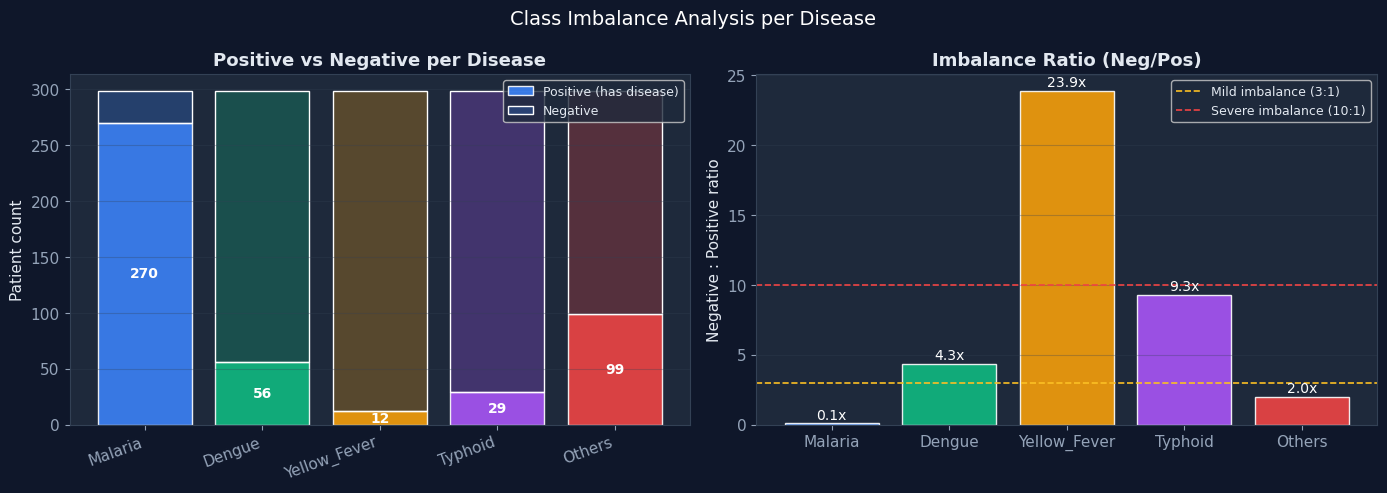


=== Imbalance Summary ===
  Malaria        : 270 positive | ratio 0.1:1  Mild
  Dengue         :  56 positive | ratio 4.3:1  Moderate
  Yellow_Fever   :  12 positive | ratio 23.9:1  SEVERE!
  Typhoid        :  29 positive | ratio 9.3:1  SEVERE!
  Others         :  99 positive | ratio 2.0:1  Mild


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance Analysis per Disease', fontsize=14, color='white')

diseases   = list(TARGET_MAP.keys())
pos_counts = [int(df[TARGET_MAP[d]].sum()) for d in diseases]
neg_counts = [int((df[TARGET_MAP[d]] == 0).sum()) for d in diseases]
ratios     = [neg/pos if pos > 0 else 0 for neg, pos in zip(neg_counts, pos_counts)]
colors     = [DISEASE_COLORS[d] for d in diseases]

# --- Left: stacked bar ---
ax = axes[0]
x  = np.arange(len(diseases))
ax.bar(x, pos_counts, label='Positive (has disease)', color=colors, alpha=0.9, edgecolor='white')
ax.bar(x, neg_counts, bottom=pos_counts, label='Negative', color=[c+'44' for c in colors], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(diseases, rotation=20, ha='right')
ax.set_ylabel('Patient count'); ax.set_title('Positive vs Negative per Disease')
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3)
for i, (p, n) in enumerate(zip(pos_counts, neg_counts)):
    ax.text(i, p/2, str(p), ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# --- Right: imbalance ratio ---
ax2 = axes[1]
bars = ax2.bar(diseases, ratios, color=colors, edgecolor='white', alpha=0.9)
ax2.axhline(3, color='#fbbf24', linestyle='--', linewidth=1.2, label='Mild imbalance (3:1)')
ax2.axhline(10, color='#ef4444', linestyle='--', linewidth=1.2, label='Severe imbalance (10:1)')
ax2.set_ylabel('Negative : Positive ratio')
ax2.set_title('Imbalance Ratio (Neg/Pos)')
ax2.legend(fontsize=9); ax2.yaxis.grid(True, alpha=0.3)
for bar, ratio in zip(bars, ratios):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{ratio:.1f}x', ha='center', fontsize=10, color='white')

plt.tight_layout()
plt.show()

print("\n=== Imbalance Summary ===")
for d, pos, ratio in zip(diseases, pos_counts, ratios):
    severity = "SEVERE!" if ratio > 8 else ("Moderate" if ratio > 3 else "Mild")
    print(f"  {d:15s}: {pos:3d} positive | ratio {ratio:.1f}:1  {severity}")


In [13]:
# Strategy justification
print("""
Imbalance Mitigation Strategy
══════════════════════════════════════════════════════════════
Strategy chosen: class_weight='balanced' (RF) + scale_pos_weight (XGBoost)

WHY NOT SMOTE?
  • Dataset is small (300 rows) — SMOTE risks generating unrealistic synthetic
    patients by interpolating between sparse minority-class examples.
  • Most features are binary (OUI/NON): SMOTE interpolation on binary features
    produces fractional values (e.g., 0.63 for a yes/no symptom), which are
    clinically meaningless and can mislead the model.

WHY class_weight='balanced'?
  • Automatically adjusts loss function weights so minority-class errors are
    penalized more heavily — no synthetic data generated.
  • Works directly on the original feature space; no risk of information leakage.
  • Validated approach for imbalanced clinical classification (He & Garcia, 2009).
══════════════════════════════════════════════════════════════
""")



Imbalance Mitigation Strategy
══════════════════════════════════════════════════════════════
Strategy chosen: class_weight='balanced' (RF) + scale_pos_weight (XGBoost)

WHY NOT SMOTE?
  • Dataset is small (300 rows) — SMOTE risks generating unrealistic synthetic
    patients by interpolating between sparse minority-class examples.
  • Most features are binary (OUI/NON): SMOTE interpolation on binary features
    produces fractional values (e.g., 0.63 for a yes/no symptom), which are
    clinically meaningless and can mislead the model.

WHY class_weight='balanced'?
  • Automatically adjusts loss function weights so minority-class errors are
    penalized more heavily — no synthetic data generated.
  • Works directly on the original feature space; no risk of information leakage.
  • Validated approach for imbalanced clinical classification (He & Garcia, 2009).
══════════════════════════════════════════════════════════════



## 4. Statistical Feature Significance Testing
### Approach
| Data Type | Test | Rationale |
|-----------|------|-----------|
| **Categorical** (OUI/NON, nominal) | **Chi-Square (χ²)** | Tests independence between categorical feature and binary disease label |
| **Numeric** (continuous lab values, vitals) | **Mann-Whitney U** | Non-parametric; does not assume normal distribution |

> **Decision rule:** Features with **p-value < 0.05** are considered statistically significant.
> Results sorted by p-value ascending — smaller p-value = stronger association.


In [14]:
from scipy.stats import chi2_contingency, mannwhitneyu

def run_statistical_tests(df, feature_cols, numeric_features, target_map):
    """
    For each disease, compute:
      - Chi2 test for categorical features
      - Mann-Whitney U for numeric features
    Returns dict of {disease: {'cat': df, 'num': df}}
    """
    results = {}
    for disease, target_col in target_map.items():
        y = df[target_col].dropna()
        idx = y.index
        res_cat, res_num = [], []

        # Categorical: Chi-Square
        for col in feature_cols:
            if col in numeric_features:
                continue
            col_data = df.loc[idx, col].fillna('MISSING')
            ct = pd.crosstab(col_data, y)
            if ct.shape[0] < 2 or ct.shape[1] < 2:
                continue
            try:
                chi2, p, dof, _ = chi2_contingency(ct)
                res_cat.append({'Feature': col, 'Statistic': round(chi2, 4),
                                'p_value': p, 'Method': 'Chi-Square', 'Type': 'Categorical'})
            except:
                pass

        # Numeric: Mann-Whitney U
        for col in numeric_features:
            if col not in df.columns:
                continue
            col_data = df.loc[idx, col]
            grp0 = col_data[y == 0].dropna()
            grp1 = col_data[y == 1].dropna()
            if len(grp0) < 2 or len(grp1) < 2:
                continue
            try:
                stat, p = mannwhitneyu(grp0, grp1, alternative='two-sided')
                res_num.append({'Feature': col, 'Statistic': round(stat, 4),
                                'p_value': p, 'Method': 'Mann-Whitney U', 'Type': 'Numeric'})
            except:
                pass

        results[disease] = {
            'cat': pd.DataFrame(res_cat).sort_values('p_value').reset_index(drop=True),
            'num': pd.DataFrame(res_num).sort_values('p_value').reset_index(drop=True)
        }
    return results

STAT_RESULTS = run_statistical_tests(df, CAT_FEATURES, NUM_FEATURES, TARGET_MAP)
print("Statistical tests complete for all 5 diseases.")


Statistical tests complete for all 5 diseases.


### 4.1 Top Significant Features per Disease
#### Categorical Features (Chi-Square Test)


Malaria — Top 10 Categorical Features (Chi-Square, p<0.05)
   Significant: 13 / 79 features


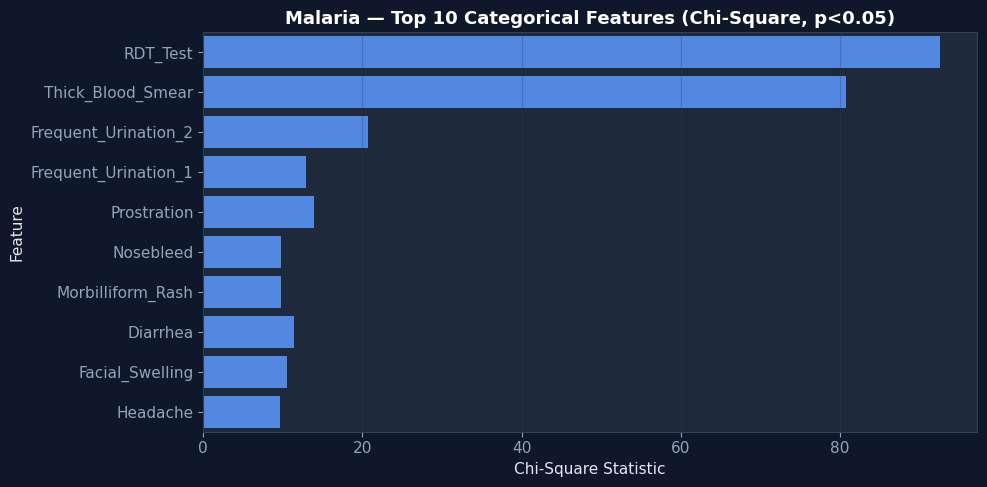


Dengue — Top 10 Categorical Features (Chi-Square, p<0.05)
   Significant: 17 / 79 features


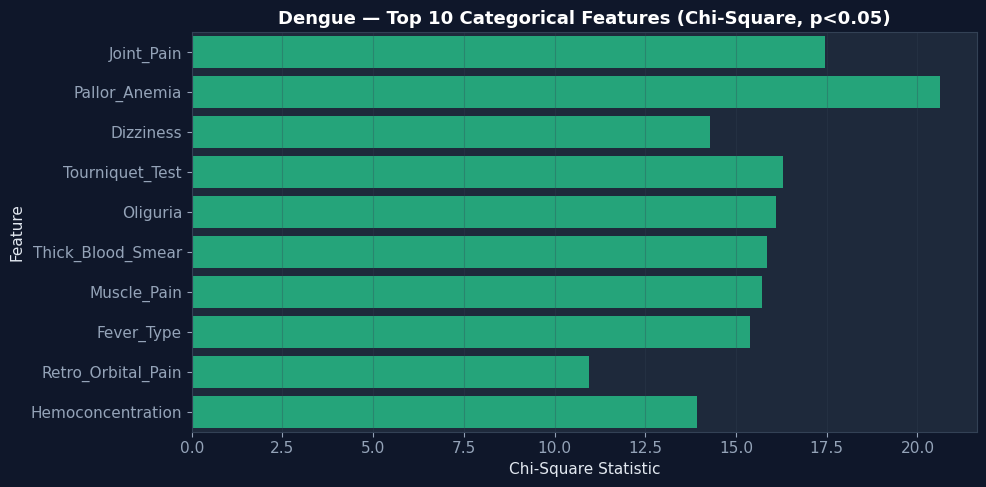


Yellow_Fever — Top 10 Categorical Features (Chi-Square, p<0.05)
   Significant: 6 / 79 features


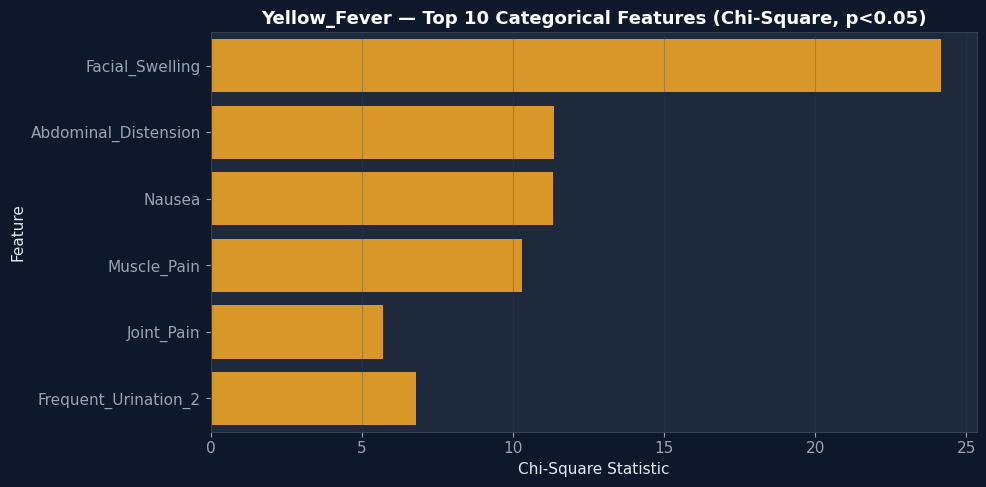


Typhoid — Top 10 Categorical Features (Chi-Square, p<0.05)
   Significant: 13 / 79 features


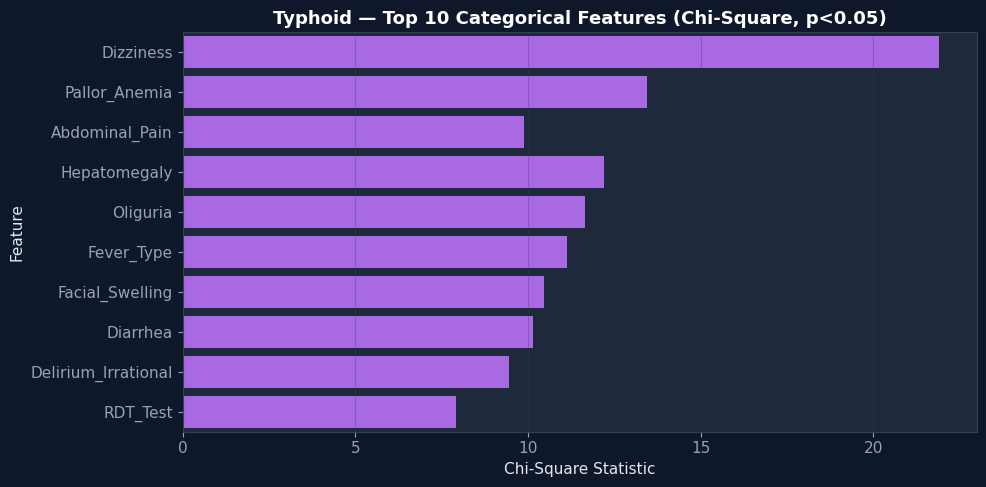


Others — Top 10 Categorical Features (Chi-Square, p<0.05)
   Significant: 25 / 79 features


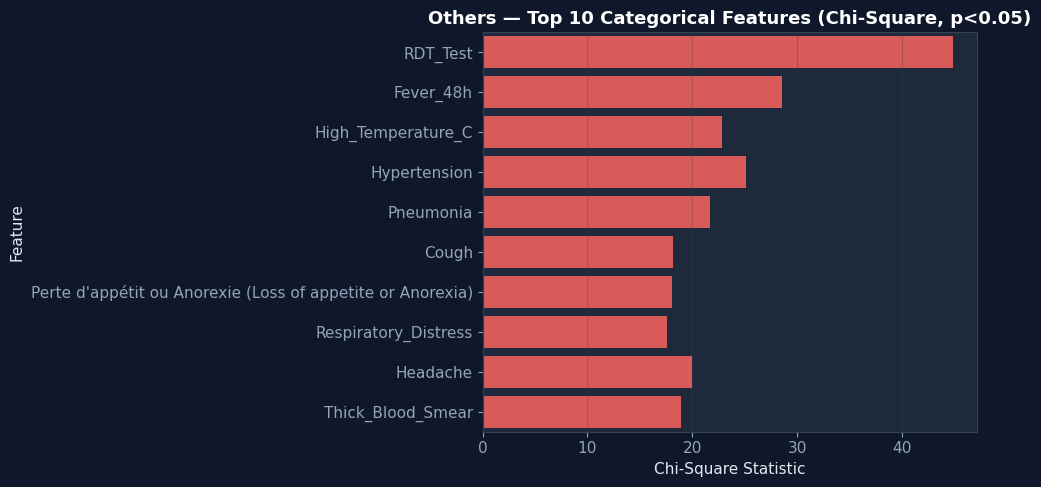

In [15]:
P_THRESHOLD = 0.05
TOP_N = 10

print("=" * 80)
for disease in TARGET_MAP:
    cat_df = STAT_RESULTS[disease]['cat']
    sig = cat_df[cat_df['p_value'] < P_THRESHOLD]
    print(f"\n{disease} — Top {TOP_N} Categorical Features (Chi-Square, p<0.05)")
    print(f"   Significant: {len(sig)} / {len(cat_df)} features")
    if not sig.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=sig.head(TOP_N), x='Statistic', y='Feature', color=DISEASE_COLORS[disease])
        plt.title(f"{disease} — Top {TOP_N} Categorical Features (Chi-Square, p<0.05)", color='white')
        plt.xlabel('Chi-Square Statistic'); plt.ylabel('Feature')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("   No significant features to plot.")


#### Numeric Features (Mann-Whitney U Test)


Malaria — Numeric Features (Mann-Whitney U, p<0.05)
   Significant: 0 / 14 features
   No significant features to plot.

Dengue — Numeric Features (Mann-Whitney U, p<0.05)
   Significant: 7 / 13 features


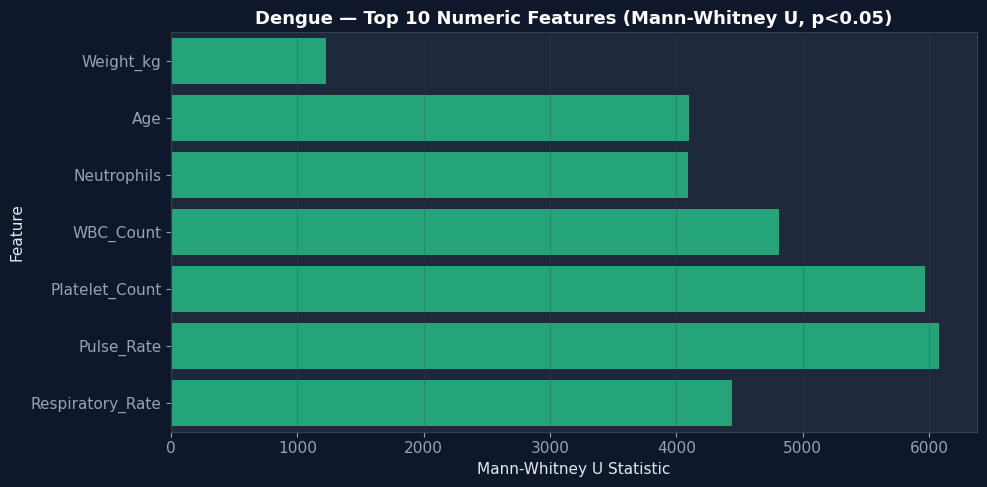


Yellow_Fever — Numeric Features (Mann-Whitney U, p<0.05)
   Significant: 0 / 13 features
   No significant features to plot.

Typhoid — Numeric Features (Mann-Whitney U, p<0.05)
   Significant: 6 / 13 features


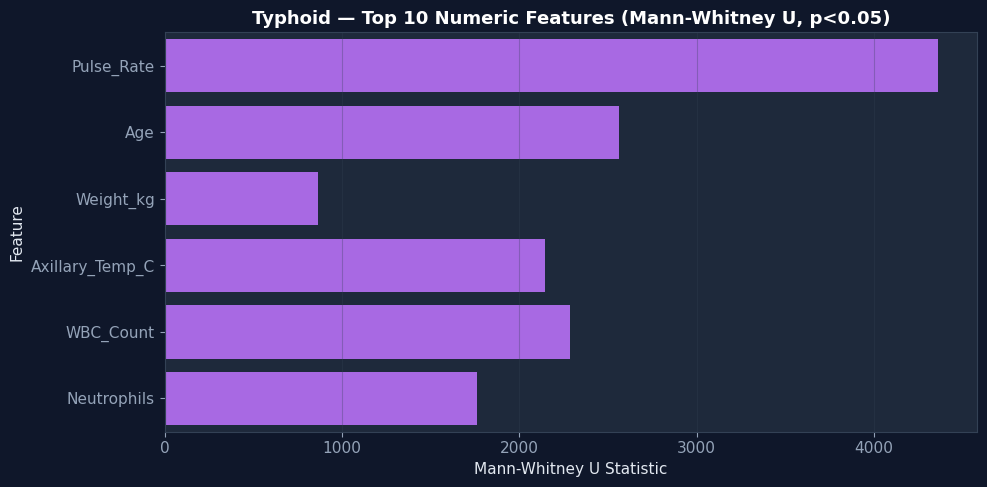


Others — Numeric Features (Mann-Whitney U, p<0.05)
   Significant: 5 / 14 features


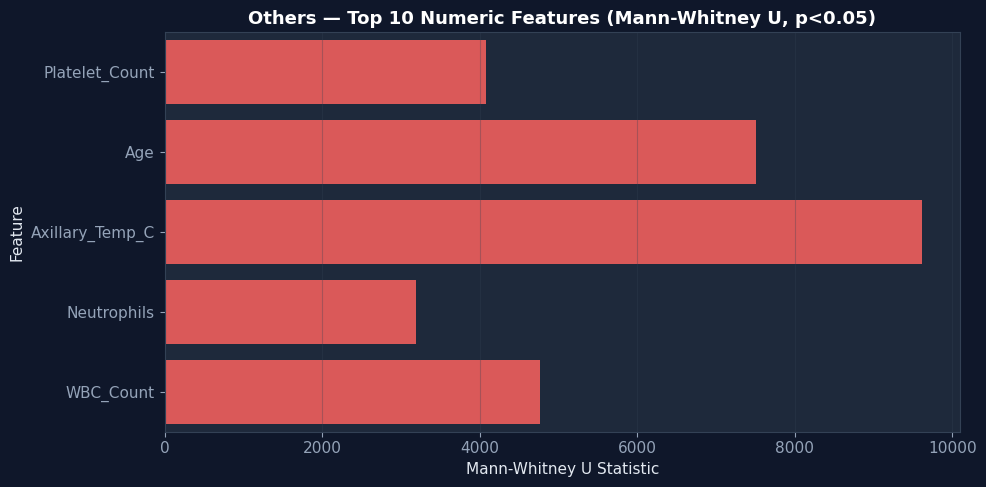

In [16]:
print("=" * 80)
for disease in TARGET_MAP:
    num_df = STAT_RESULTS[disease]['num']
    sig = num_df[num_df['p_value'] < P_THRESHOLD]
    print(f"\n{disease} — Numeric Features (Mann-Whitney U, p<0.05)")
    print(f"   Significant: {len(sig)} / {len(num_df)} features")
    if not sig.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=sig.head(TOP_N), x='Statistic', y='Feature', color=DISEASE_COLORS[disease])
        plt.title(f"{disease} — Top {TOP_N} Numeric Features (Mann-Whitney U, p<0.05)", color='white')
        plt.xlabel('Mann-Whitney U Statistic'); plt.ylabel('Feature')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("   No significant features to plot.")

## 5. Visualizations
### Strategy
- **Categorical features** → Bar chart of proportions (positive/negative class)
- **Numeric features** → Boxplot (distribution comparison per class)
- Top 2–3 features per disease visualized


In [17]:
def get_top_features(disease, top_cat=3, top_num=2, p_thresh=0.05):
    cat_sig = STAT_RESULTS[disease]['cat']
    cat_sig = cat_sig[cat_sig['p_value'] < p_thresh].head(top_cat)['Feature'].tolist()
    num_sig = STAT_RESULTS[disease]['num']
    num_sig = num_sig[num_sig['p_value'] < p_thresh].head(top_num)['Feature'].tolist()
    return cat_sig, num_sig

for d in TARGET_MAP:
    c, n = get_top_features(d)
    print(f"{d:15s} | CAT: {c[:2]} | NUM: {n}")


Malaria         | CAT: ['RDT_Test', 'Thick_Blood_Smear'] | NUM: []
Dengue          | CAT: ['Joint_Pain', 'Pallor_Anemia'] | NUM: ['Weight_kg', 'Age']
Yellow_Fever    | CAT: ['Facial_Swelling', 'Abdominal_Distension'] | NUM: []
Typhoid         | CAT: ['Dizziness', 'Pallor_Anemia'] | NUM: ['Pulse_Rate', 'Age']
Others          | CAT: ['RDT_Test', 'Fever_48h'] | NUM: ['Platelet_Count', 'Age']


### 5.1 Malaria — Key Feature Visualizations

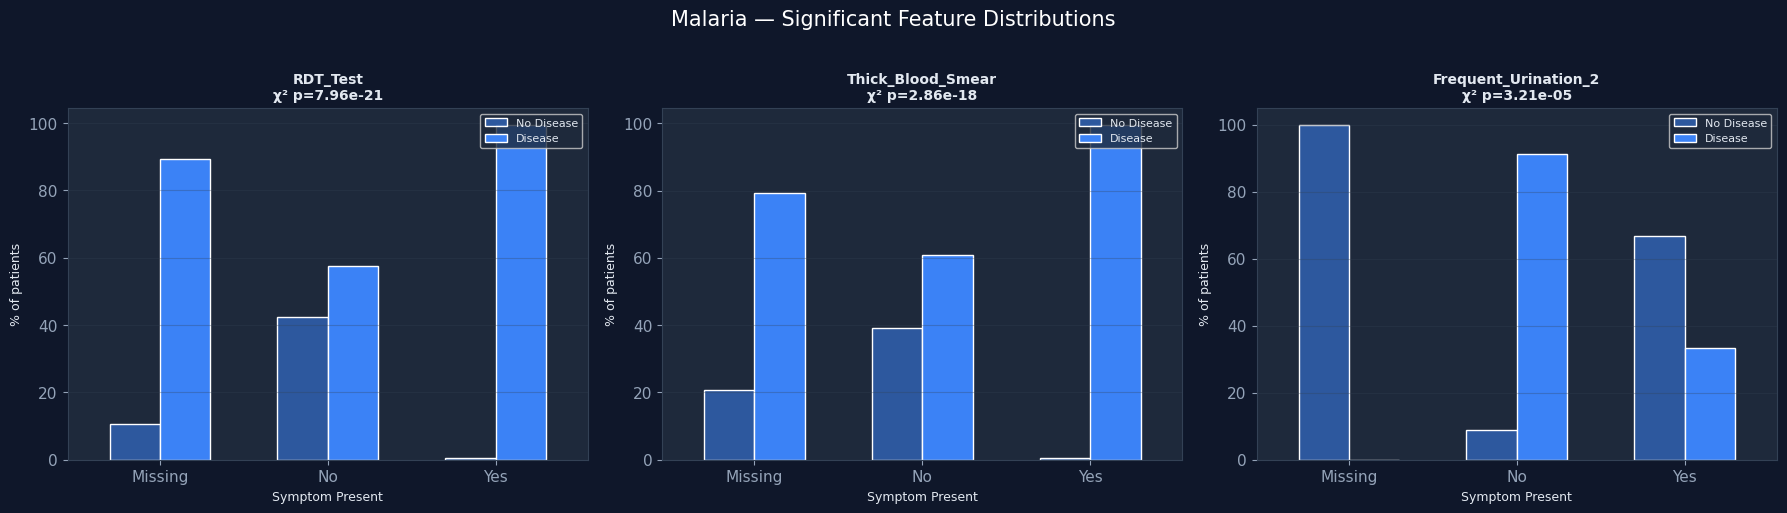

In [18]:
disease = 'Malaria'
color = DISEASE_COLORS[disease]
target_col = TARGET_MAP[disease]
cat_feats, num_feats = get_top_features(disease, top_cat=3, top_num=1)

fig, axes = plt.subplots(1, len(cat_feats) + len(num_feats), figsize=(6*(len(cat_feats)+len(num_feats)), 5))
fig.suptitle(f'{disease} — Significant Feature Distributions', fontsize=15, color='white', y=1.02)

for i, feat in enumerate(cat_feats):
    ax = axes[i]
    ct = pd.crosstab(df[feat].map({1:'Yes', 0:'No'}).fillna('Missing'), df[target_col])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=[color+'88', color], edgecolor='white', width=0.6)
    p_val = STAT_RESULTS[disease]['cat']
    p_val = p_val[p_val['Feature'] == feat]['p_value'].values[0]
    ax.set_title(f'{feat}\nχ² p={p_val:.2e}', fontsize=10)
    ax.set_xlabel('Symptom Present', fontsize=9)
    ax.set_ylabel('% of patients', fontsize=9)
    ax.legend(['No Disease', 'Disease'], loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.grid(True, alpha=0.3)

for j, feat in enumerate(num_feats):
    ax = axes[len(cat_feats) + j]
    grp0 = df[df[target_col] == 0][feat].dropna()
    grp1 = df[df[target_col] == 1][feat].dropna()
    bp = ax.boxplot([grp0, grp1], labels=[f'No {disease}', disease],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(color + '44')
    bp['boxes'][1].set_facecolor(color)
    p_val = STAT_RESULTS[disease]['num']
    p_val = p_val[p_val['Feature'] == feat]['p_value'].values[0]
    ax.set_title(f'{feat}\nMann-Whitney p={p_val:.2e}', fontsize=10)
    ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.2 Dengue — Key Feature Visualizations

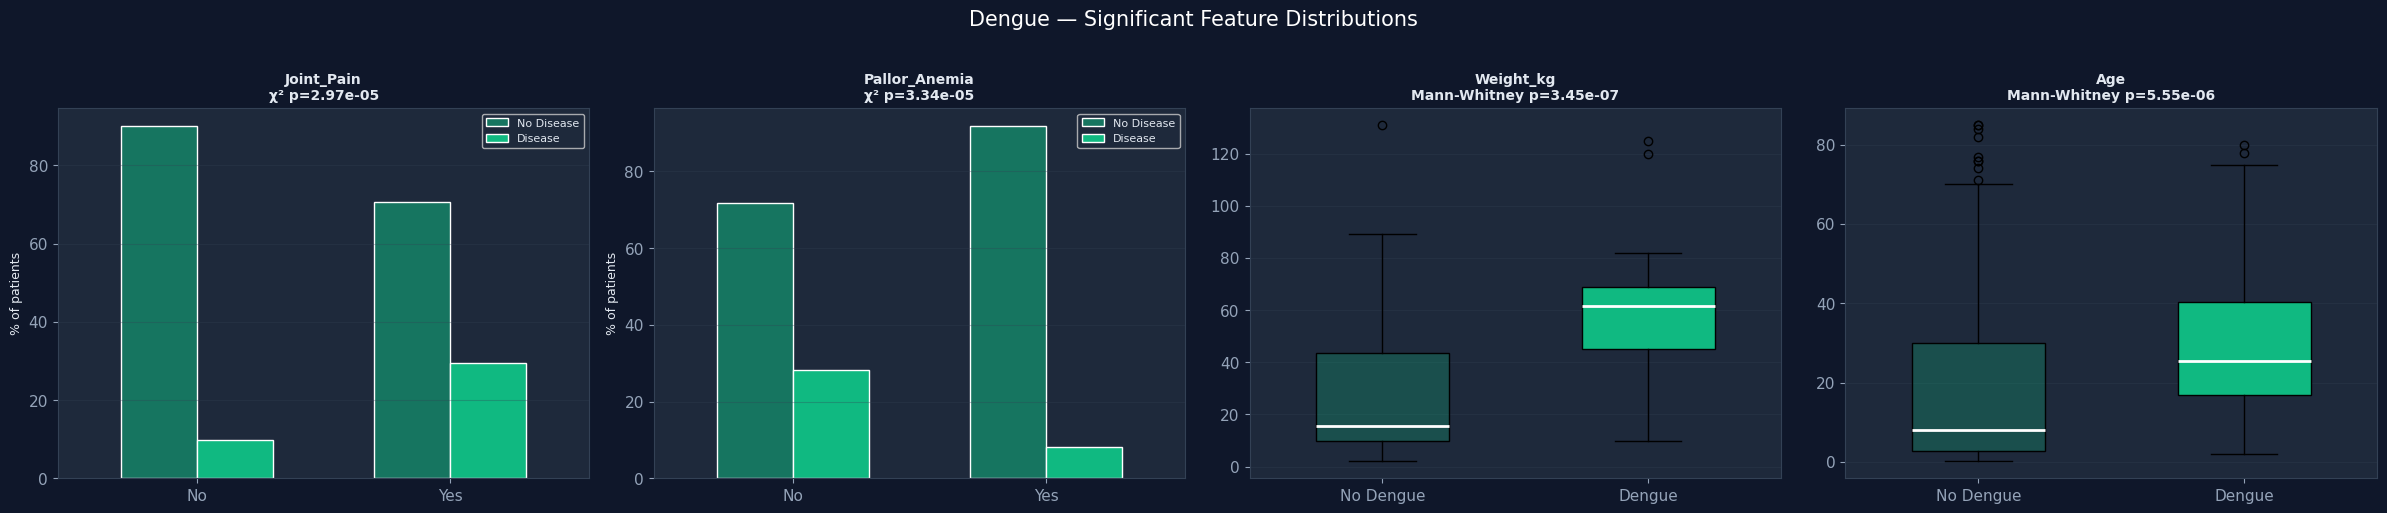

In [19]:
disease = 'Dengue'
color = DISEASE_COLORS[disease]
target_col = TARGET_MAP[disease]
cat_feats, num_feats = get_top_features(disease, top_cat=2, top_num=2)

fig, axes = plt.subplots(1, len(cat_feats) + len(num_feats), figsize=(6*(len(cat_feats)+len(num_feats)), 5))
fig.suptitle(f'{disease} — Significant Feature Distributions', fontsize=15, color='white', y=1.02)

for i, feat in enumerate(cat_feats):
    ax = axes[i]
    ct = pd.crosstab(df[feat].map({1:'Yes', 0:'No'}), df[target_col])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=[color+'88', color], edgecolor='white', width=0.6)
    p_val = STAT_RESULTS[disease]['cat']
    p_val = p_val[p_val['Feature'] == feat]['p_value'].values[0]
    ax.set_title(f'{feat}\nχ² p={p_val:.2e}', fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('% of patients', fontsize=9)
    ax.legend(['No Disease', 'Disease'], fontsize=8)
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.grid(True, alpha=0.3)

for j, feat in enumerate(num_feats):
    ax = axes[len(cat_feats) + j]
    grp0 = df[df[target_col] == 0][feat].dropna()
    grp1 = df[df[target_col] == 1][feat].dropna()
    bp = ax.boxplot([grp0, grp1], labels=[f'No {disease}', disease],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(color + '44')
    bp['boxes'][1].set_facecolor(color)
    p_val = STAT_RESULTS[disease]['num']
    p_val = p_val[p_val['Feature'] == feat]['p_value'].values[0]
    ax.set_title(f'{feat}\nMann-Whitney p={p_val:.2e}', fontsize=10)
    ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.3 Typhoid Fever — Key Feature Visualizations

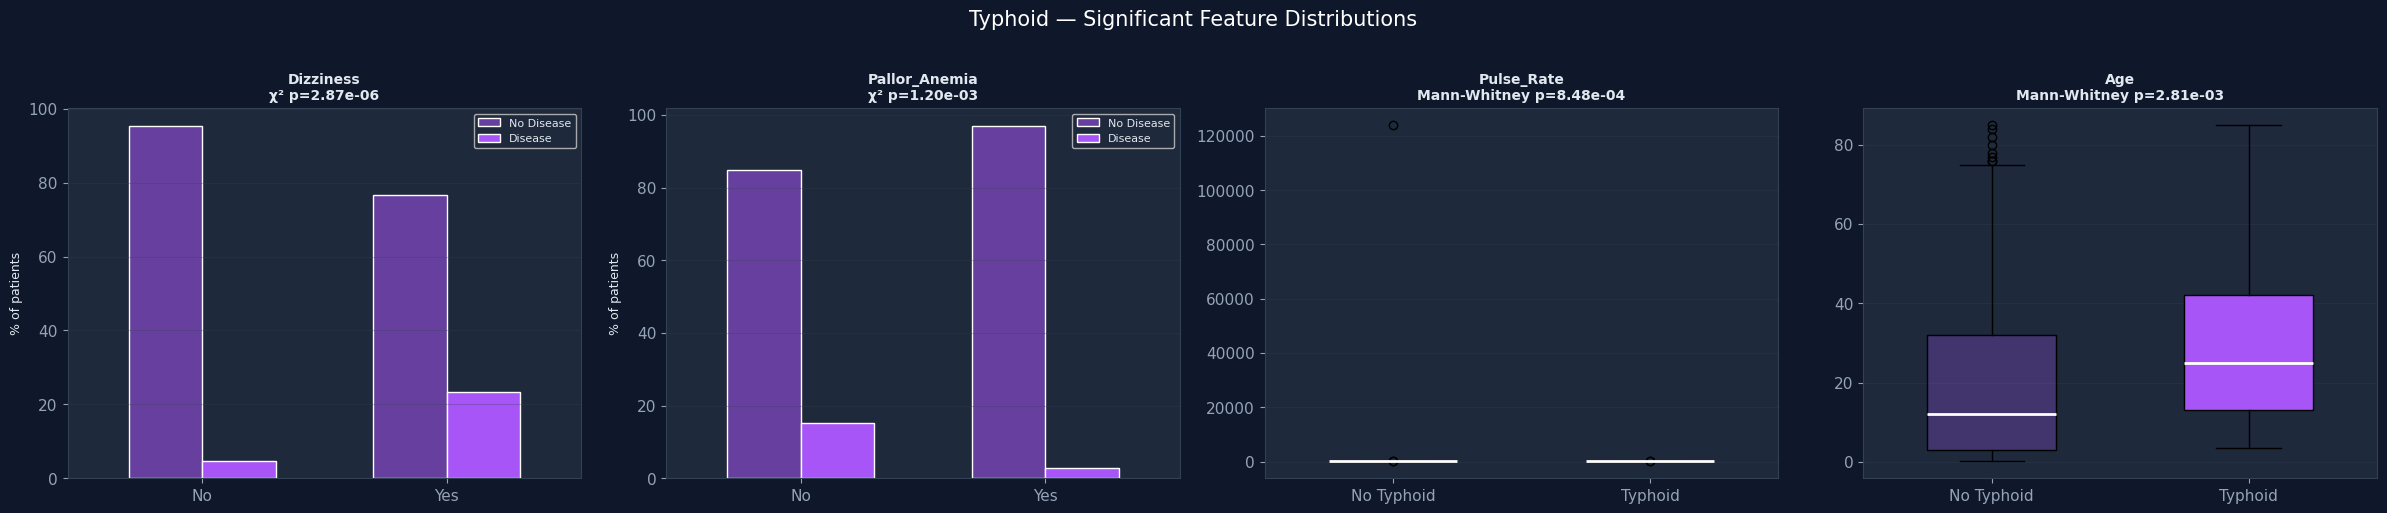

In [20]:
disease = 'Typhoid'
color = DISEASE_COLORS[disease]
target_col = TARGET_MAP[disease]
cat_feats, num_feats = get_top_features(disease, top_cat=2, top_num=2)

fig, axes = plt.subplots(1, len(cat_feats) + len(num_feats), figsize=(6*(len(cat_feats)+len(num_feats)), 5))
fig.suptitle(f'{disease} — Significant Feature Distributions', fontsize=15, color='white', y=1.02)

for i, feat in enumerate(cat_feats):
    ax = axes[i]
    ct = pd.crosstab(df[feat].map({1:'Yes', 0:'No'}), df[target_col])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=[color+'88', color], edgecolor='white', width=0.6)
    p_val = STAT_RESULTS[disease]['cat']
    p_val = p_val[p_val['Feature'] == feat]['p_value'].values[0]
    ax.set_title(f'{feat}\nχ² p={p_val:.2e}', fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('% of patients', fontsize=9)
    ax.legend(['No Disease', 'Disease'], fontsize=8)
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.grid(True, alpha=0.3)

for j, feat in enumerate(num_feats):
    ax = axes[len(cat_feats) + j]
    grp0 = df[df[target_col] == 0][feat].dropna()
    grp1 = df[df[target_col] == 1][feat].dropna()
    bp = ax.boxplot([grp0, grp1], labels=[f'No {disease}', disease],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(color + '44')
    bp['boxes'][1].set_facecolor(color)
    p_val = STAT_RESULTS[disease]['num']
    p_val = p_val[p_val['Feature'] == feat]['p_value'].values[0]
    ax.set_title(f'{feat}\nMann-Whitney p={p_val:.2e}', fontsize=10)
    ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.4 P-value Heatmap — Top Features Across All Diseases

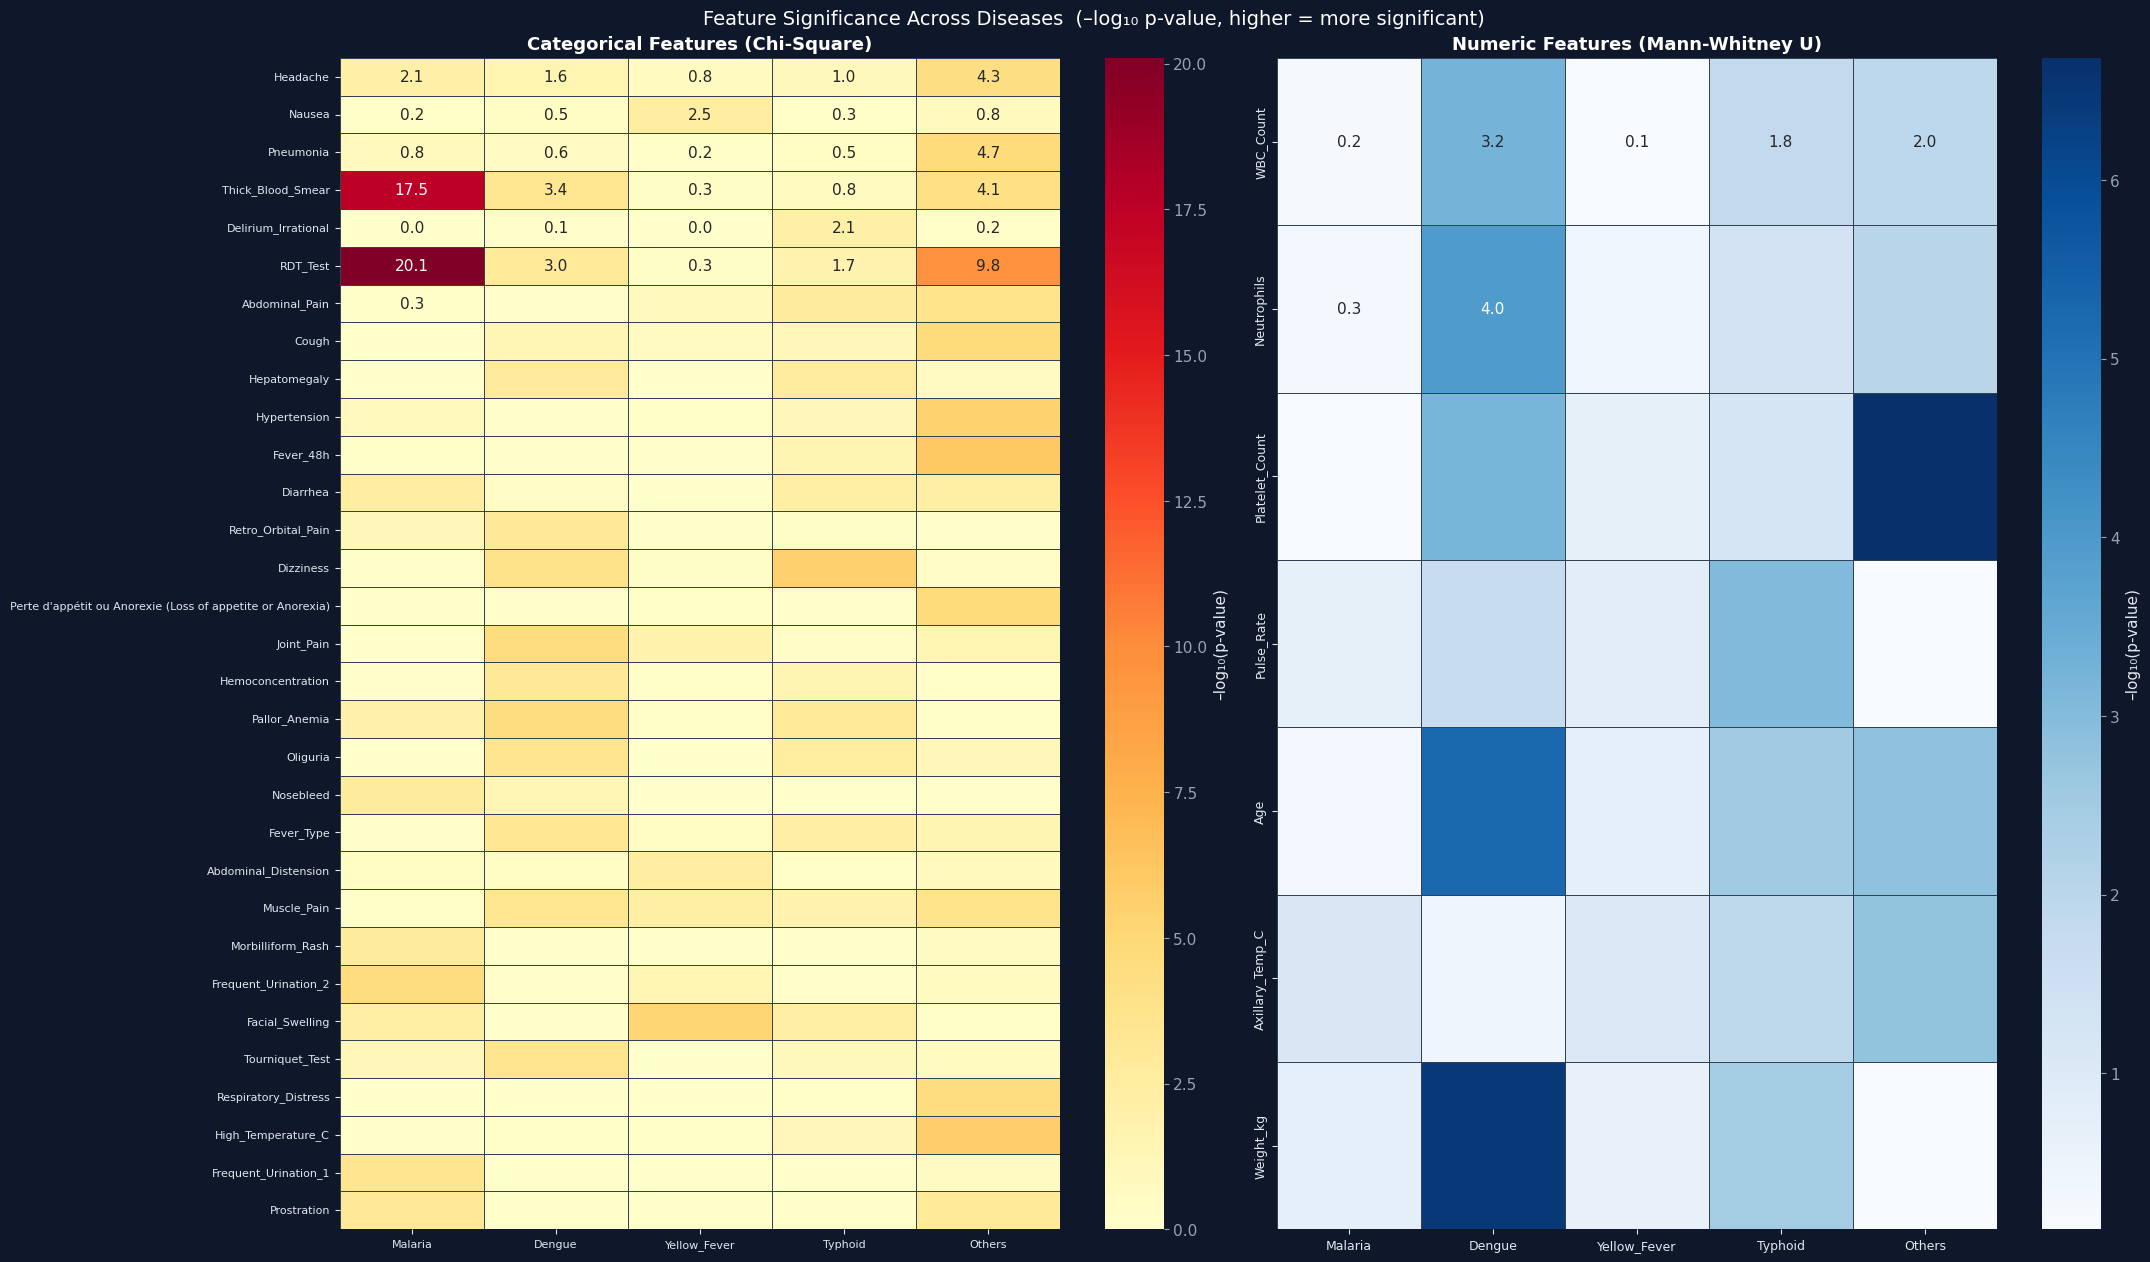

In [21]:
# Collect union of top 10 significant categorical features per disease
all_sig_cats = set()
for disease in TARGET_MAP:
    top = STAT_RESULTS[disease]['cat']
    top = top[top['p_value'] < 0.05].head(10)['Feature'].tolist()
    all_sig_cats.update(top)

all_sig_nums = set()
for disease in TARGET_MAP:
    top = STAT_RESULTS[disease]['num']
    top = top[top['p_value'] < 0.05].head(5)['Feature'].tolist()
    all_sig_nums.update(top)

# Build p-value matrix
def build_pval_matrix(sig_features, feat_type='cat'):
    rows = {}
    for feat in sig_features:
        row = {}
        for disease in TARGET_MAP:
            df_res = STAT_RESULTS[disease][feat_type]
            match = df_res[df_res['Feature'] == feat]['p_value']
            row[disease] = match.values[0] if len(match) else 1.0
        rows[feat] = row
    return pd.DataFrame(rows).T

# --- Categorical heatmap ---
pval_cat = build_pval_matrix(all_sig_cats, 'cat')
pval_cat_log = -np.log10(pval_cat.clip(1e-30, 1))

fig, axes = plt.subplots(1, 2, figsize=(22, max(6, len(all_sig_cats)*0.35 + 2)))
fig.suptitle('Feature Significance Across Diseases  (–log₁₀ p-value, higher = more significant)',
             fontsize=14, color='white')

# Categorical
sns.heatmap(pval_cat_log, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#334155',
            cbar_kws={'label': '–log₁₀(p-value)'})
axes[0].set_title('Categorical Features (Chi-Square)', color='white')
axes[0].tick_params(colors='#e2e8f0', labelsize=8)

# Numeric
pval_num = build_pval_matrix(all_sig_nums, 'num')
pval_num_log = -np.log10(pval_num.clip(1e-30, 1))
sns.heatmap(pval_num_log, ax=axes[1], cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#334155',
            cbar_kws={'label': '–log₁₀(p-value)'})
axes[1].set_title('Numeric Features (Mann-Whitney U)', color='white')
axes[1].tick_params(colors='#e2e8f0', labelsize=9)

plt.tight_layout()
plt.show()


## 6. Top Feature Selection for Modeling
Select **top 5–10 significant features** per disease (sorted by p-value ascending), combining categorical and numeric.


In [22]:
TOP_K = 8
selected_features = {}

print("=" * 70)
for disease in TARGET_MAP:
    cat_sig = STAT_RESULTS[disease]['cat']
    cat_sig = cat_sig[cat_sig['p_value'] < 0.05].head(TOP_K)
    num_sig = STAT_RESULTS[disease]['num']
    num_sig = num_sig[num_sig['p_value'] < 0.05].head(TOP_K)

    # Combine & pick top K total, sorted by p-value
    combined = pd.concat([cat_sig, num_sig]).sort_values('p_value').head(TOP_K)
    selected_features[disease] = combined['Feature'].tolist()

    print(f"\n{disease} — Top {TOP_K} Features (p<0.05, sorted by p-value):")
    print(combined[['Feature','Method','p_value']].to_string(index=False))

print("\nFeature selection complete.")



Malaria — Top 8 Features (p<0.05, sorted by p-value):
             Feature     Method      p_value
            RDT_Test Chi-Square 7.959667e-21
   Thick_Blood_Smear Chi-Square 2.855882e-18
Frequent_Urination_2 Chi-Square 3.214228e-05
Frequent_Urination_1 Chi-Square 3.276217e-04
         Prostration Chi-Square 9.272967e-04
           Nosebleed Chi-Square 1.742145e-03
   Morbilliform_Rash Chi-Square 1.742145e-03
            Diarrhea Chi-Square 3.405012e-03

Dengue — Top 8 Features (p<0.05, sorted by p-value):
        Feature         Method      p_value
      Weight_kg Mann-Whitney U 3.449209e-07
            Age Mann-Whitney U 5.551979e-06
     Joint_Pain     Chi-Square 2.967438e-05
  Pallor_Anemia     Chi-Square 3.344893e-05
    Neutrophils Mann-Whitney U 1.104113e-04
      Dizziness     Chi-Square 1.576240e-04
Tourniquet_Test     Chi-Square 2.911221e-04
       Oliguria     Chi-Square 3.175507e-04

Yellow_Fever — Top 8 Features (p<0.05, sorted by p-value):
             Feature     Metho

## 7. Model Building — Binary Classifier per Disease
For each disease, train a **Random Forest** and **XGBoost** classifier using its selected features.
Multi-label is handled by training one binary classifier per disease (Binary Relevance strategy).


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score, precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# EXCLUDE DIAGNOSTIC LEAKAGE FEATURES
LEAKAGE_FEATURES = ['RDT_Test', 'Thick_Blood_Smear']

def prepare_XY_clean(disease, df, target_map):
    all_targets = list(target_map.values())
    feature_cols = [col for col in df.columns if col not in all_targets and col not in LEAKAGE_FEATURES and col != 'Patient_ID']
    
    target_col = target_map[disease]
    subset = df.dropna(subset=[target_col]).copy()
    
    X = subset[feature_cols].copy()
    y = subset[target_col].astype(int)
    for col in X.select_dtypes(include='object').columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y, feature_cols
model_results = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for disease in TARGET_MAP:
    X, y, feature_cols = prepare_XY_clean(disease, df, TARGET_MAP)
    
    if y.nunique() < 2:
        print(f"{disease}: only one class, skipping.")
        continue
    rf_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=8)), # Seleksi 8 fitur DALAM pipeline
        ('model', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
    ])
    scale_pos = (y == 0).sum() / (y == 1).sum() if (y == 1).sum() > 0 else 1
    xgb_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=8)),
        ('model', XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos,
                                eval_metric='logloss', random_state=42, verbosity=0))
    ])
    y_pred_rf = cross_val_predict(rf_pipe, X, y, cv=cv, method='predict_proba')[:, 1]
    y_bin_rf = (y_pred_rf >= 0.5).astype(int)

    y_pred_xgb = cross_val_predict(xgb_pipe, X, y, cv=cv, method='predict_proba')[:, 1]
    y_bin_xgb = (y_pred_xgb >= 0.5).astype(int)

    model_results[disease] = {
        'RF':  {'auc': roc_auc_score(y, y_pred_rf),
                'f1':  f1_score(y, y_bin_rf, zero_division=0),
                'prec': precision_score(y, y_bin_rf, zero_division=0),
                'rec':  recall_score(y, y_bin_rf, zero_division=0),
                'acc':  accuracy_score(y, y_bin_rf)},
        'XGB': {'auc': roc_auc_score(y, y_pred_xgb),
                'f1':  f1_score(y, y_bin_xgb, zero_division=0),
                'prec': precision_score(y, y_bin_xgb, zero_division=0),
                'rec':  recall_score(y, y_bin_xgb, zero_division=0),
                'acc':  accuracy_score(y, y_bin_xgb)},
        'n_samples': len(y), 'n_pos': int(y.sum()),
        'n_features': 8 # K=8
    }
    print(f"{disease}: RF AUC={model_results[disease]['RF']['auc']:.3f}  |  XGB AUC={model_results[disease]['XGB']['auc']:.3f}")


Malaria: RF AUC=1.000  |  XGB AUC=1.000
Dengue: RF AUC=0.998  |  XGB AUC=0.994
Yellow_Fever: RF AUC=0.989  |  XGB AUC=1.000
Typhoid: RF AUC=0.967  |  XGB AUC=0.950
Others: RF AUC=1.000  |  XGB AUC=0.997


### 7.1 Model Performance Summary

     Disease Model  AUC-ROC       F1  Precision   Recall  Accuracy Pos/Total
     Malaria    RF 1.000000 0.998152   0.996310 1.000000  0.996656   270/299
     Malaria   XGB 1.000000 1.000000   1.000000 1.000000  1.000000   270/299
      Dengue    RF 0.998347 0.955752   0.947368 0.964286  0.983278    56/299
      Dengue   XGB 0.994342 0.972973   0.981818 0.964286  0.989967    56/299
Yellow_Fever    RF 0.989257 0.666667   1.000000 0.500000  0.979933    12/299
Yellow_Fever   XGB 1.000000 1.000000   1.000000 1.000000  1.000000    12/299
     Typhoid    RF 0.967433 0.925926   1.000000 0.862069  0.986622    29/299
     Typhoid   XGB 0.949681 0.912281   0.928571 0.896552  0.983278    29/299
      Others    RF 0.999646 0.979381   1.000000 0.959596  0.986622    99/299
      Others   XGB 0.996970 0.984615   1.000000 0.969697  0.989967    99/299


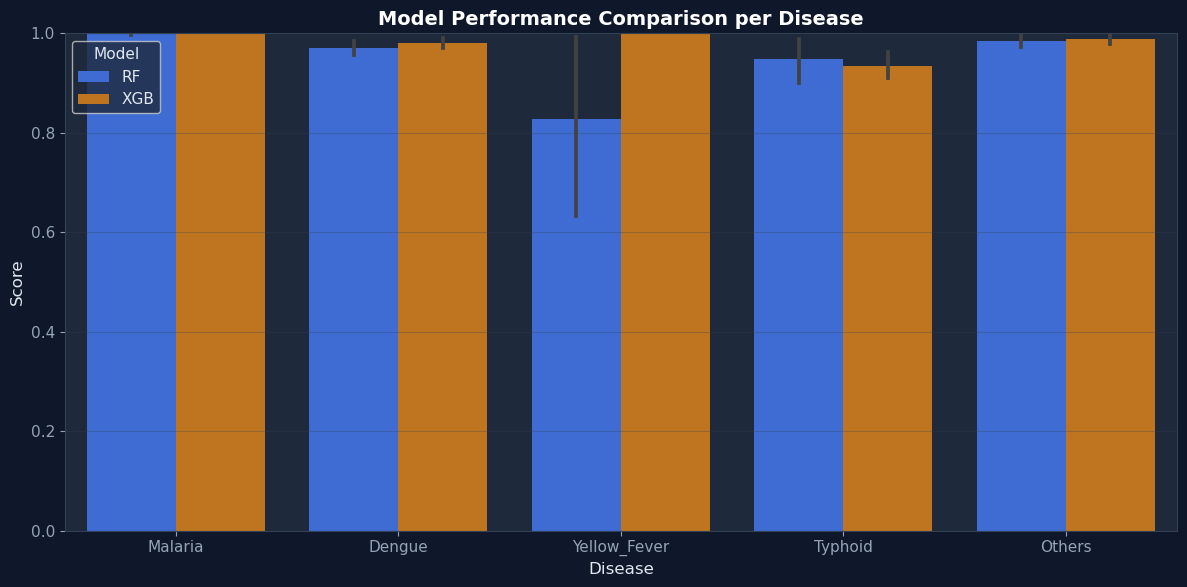

In [ ]:
rows = []
for disease, res in model_results.items():
    for model_name in ['RF', 'XGB']:
        rows.append({
            'Disease': disease,
            'Model': model_name,
            'AUC-ROC': res[model_name]['auc'],
            'F1': res[model_name]['f1'],
            'Precision': res[model_name]['prec'],
            'Recall': res[model_name]['rec'],
            'Accuracy': res[model_name]['acc'],
            'Pos/Total': f"{res['n_pos']}/{res['n_samples']}"
        })

perf_df = pd.DataFrame(rows)
print(perf_df.to_string(index=False))
plot_df = perf_df.melt(id_vars=['Disease', 'Model', 'Pos/Total'], value_vars=['AUC-ROC', 'F1', 'Precision', 'Recall', 'Accuracy'],
                       var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Disease', y='Score', hue='Model', palette=['#2563eb', '#d97706'])
plt.title('Model Performance Comparison per Disease', fontsize=14, color='white')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Disease', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='Model')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 7.2 Performance Bar Chart

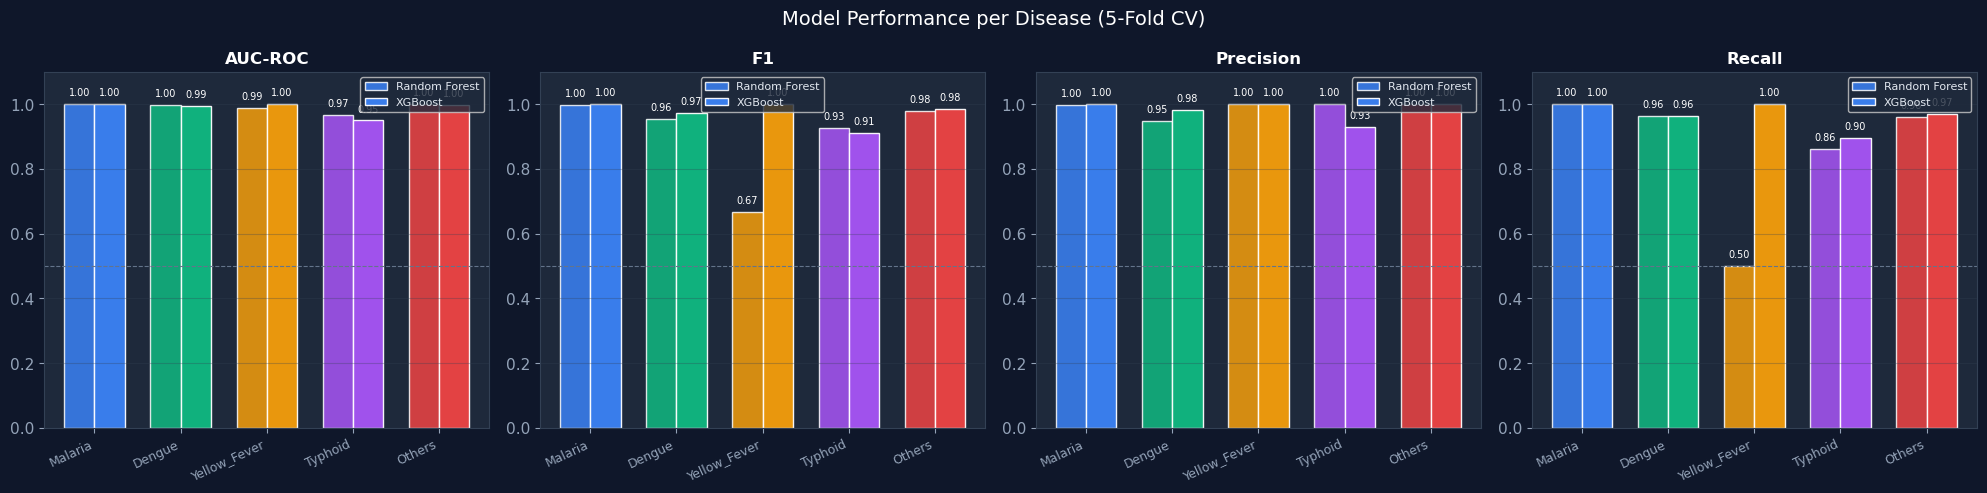

In [25]:
metrics = ['AUC-ROC', 'F1', 'Precision', 'Recall']
diseases = list(model_results.keys())

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle('Model Performance per Disease (5-Fold CV)', fontsize=14, color='white')

metric_key_map = {
    'AUC-ROC': 'auc',
    'F1': 'f1',
    'Precision': 'prec',
    'Recall': 'rec'
}

for ax, metric in zip(axes, metrics):
    rf_vals  = [model_results[d]['RF'][metric_key_map[metric]] for d in diseases]
    xgb_vals = [model_results[d]['XGB'][metric_key_map[metric]] for d in diseases]

    x = np.arange(len(diseases))
    w = 0.35
    bars1 = ax.bar(x - w/2, rf_vals, w, label='Random Forest', alpha=0.85,
                   color=[DISEASE_COLORS[d] + '99' for d in diseases], edgecolor='white')
    bars2 = ax.bar(x + w/2, xgb_vals, w, label='XGBoost', alpha=0.95,
                   color=[DISEASE_COLORS[d] for d in diseases], edgecolor='white')

    ax.set_title(metric, color='white', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(diseases, rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='#64748b', linestyle='--', linewidth=0.8)
    ax.yaxis.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='white')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='white')

plt.tight_layout()
plt.show()

### 7.3 Feature Importance (Best Model per Disease)

## 7.4 Hyperparameter Tuning — RandomizedSearchCV

We use **RandomizedSearchCV** (faster than GridSearch for large spaces) with 5-fold stratified CV to find optimal hyperparameters for both Random Forest and XGBoost per disease.
The best model per disease is selected based on **AUC-ROC** (more robust than accuracy under class imbalance).


In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Hyperparameter search spaces for Pipeline ──
rf_param_dist = {
    'model__n_estimators':      [100, 200, 300, 500],
    'model__max_depth':         [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2', 0.5],
    'model__class_weight':      ['balanced', 'balanced_subsample']
}

xgb_param_dist = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 5, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample':     [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_results = {}

print("Starting hyperparameter tuning (RandomizedSearchCV, n_iter=30 per model)...")
print("=" * 65)

for disease in TARGET_MAP:
    X, y, feature_cols = prepare_XY_clean(disease, df, TARGET_MAP)
    
    if y.nunique() < 2:
        print(f"{disease}: single class, skipped.")
        continue

    scale_pos = float((y == 0).sum()) / float((y == 1).sum())

    # ── Random Forest Pipeline ──
    rf_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=8)),
        ('model', RandomForestClassifier(random_state=42))
    ])
    
    rf_search = RandomizedSearchCV(
        rf_pipe,
        rf_param_dist, n_iter=30, cv=cv,
        scoring='roc_auc', n_jobs=-1, random_state=42, verbose=0
    )
    rf_search.fit(X, y)

    # ── XGBoost Pipeline ──
    xgb_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=8)),
        ('model', XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42, verbosity=0))
    ])
    
    xgb_search = RandomizedSearchCV(
        xgb_pipe,
        xgb_param_dist, n_iter=30, cv=cv,
        scoring='roc_auc', n_jobs=-1, random_state=42, verbose=0
    )
    xgb_search.fit(X, y)

    best_rf_auc  = rf_search.best_score_
    best_xgb_auc = xgb_search.best_score_

    # Pick overall best
    if best_rf_auc >= best_xgb_auc:
        best_pipe       = rf_search.best_estimator_
        best_model_name = 'Random Forest'
        best_auc        = best_rf_auc
    else:
        best_pipe       = xgb_search.best_estimator_
        best_model_name = 'XGBoost'
        best_auc        = best_xgb_auc

    # Extract selected features from the fitted pipeline
    mask = best_pipe.named_steps['selector'].get_support()
    sel_feats = np.array(feature_cols)[mask].tolist()

    tuned_results[disease] = {
        'best_pipe':       best_pipe,
        'best_model_name': best_model_name,
        'best_auc':        best_auc,
        'rf_auc':          best_rf_auc,
        'xgb_auc':         best_xgb_auc,
        'rf_params':       rf_search.best_params_,
        'xgb_params':      xgb_search.best_params_,
        'X': X, 'y': y,
        'selected_features': sel_feats,
        'feature_cols': feature_cols
    }
    print(f"\n{disease}")
    print(f"   RF  best AUC: {best_rf_auc:.4f}")
    print(f"   XGB best AUC: {best_xgb_auc:.4f}")
    print(f"   → Best model: {best_model_name} (AUC = {best_auc:.4f})")

print("\nHyperparameter tuning complete.")


Starting hyperparameter tuning (RandomizedSearchCV, n_iter=30 per model)...


/home/brenandacaesa/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/brenandacaesa/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/brenandacaesa/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/brenandacaesa/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



Malaria
   RF  best AUC: 1.0000
   XGB best AUC: 1.0000
   → Best model: Random Forest (AUC = 1.0000)

Dengue
   RF  best AUC: 0.9993
   XGB best AUC: 0.9996
   → Best model: XGBoost (AUC = 0.9996)

Yellow_Fever
   RF  best AUC: 1.0000
   XGB best AUC: 1.0000
   → Best model: Random Forest (AUC = 1.0000)

Typhoid
   RF  best AUC: 0.9895
   XGB best AUC: 0.9778
   → Best model: Random Forest (AUC = 0.9895)

Others
   RF  best AUC: 1.0000
   XGB best AUC: 1.0000
   → Best model: Random Forest (AUC = 1.0000)

Hyperparameter tuning complete.


### 7.5 Tuning Results — Before vs After Comparison

Performance comparison complete.


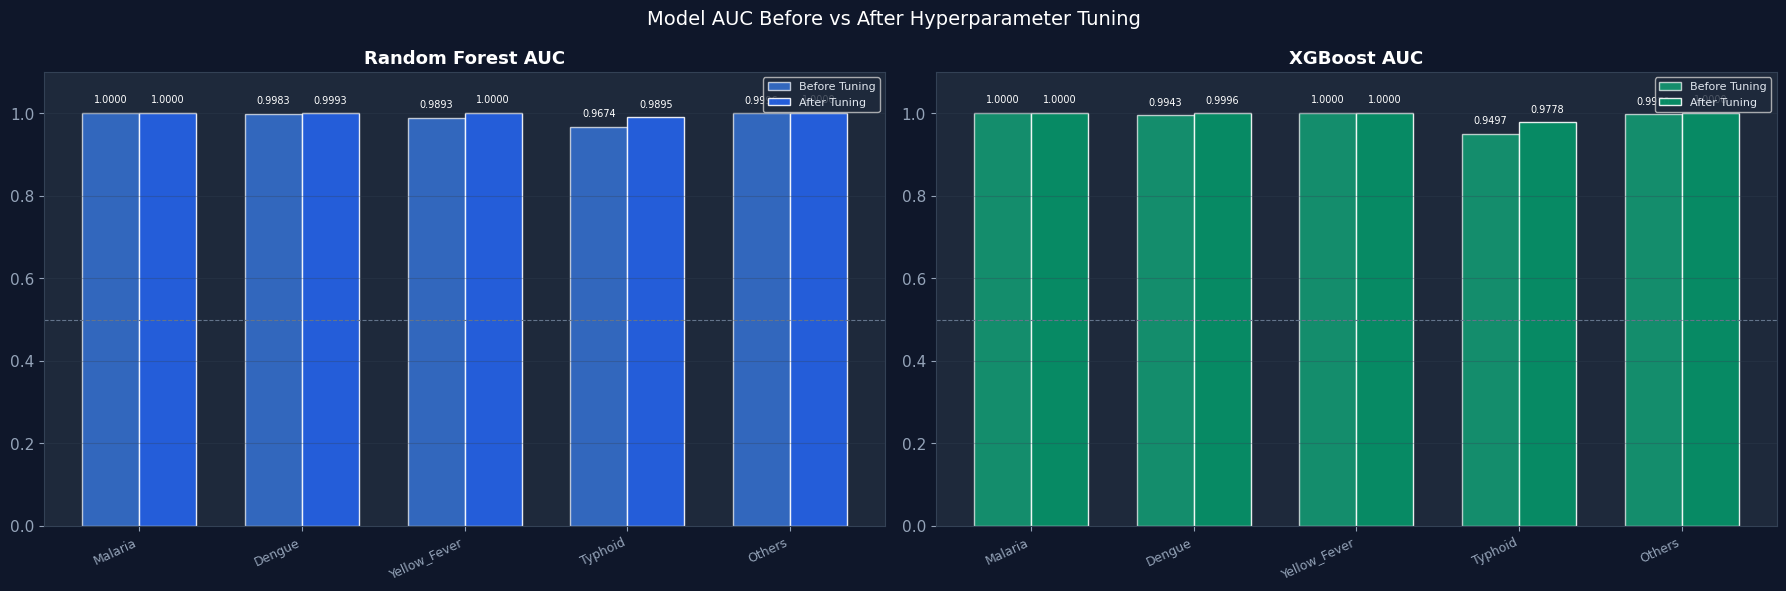

In [27]:
comparison_rows = []
for disease in tuned_results:
    # Before tuning (from model_results)
    if disease in model_results:
        before_rf  = model_results[disease]['RF']['auc']
        before_xgb = model_results[disease]['XGB']['auc']
    else:
        before_rf = before_xgb = None

    after_rf  = tuned_results[disease]['rf_auc']
    after_xgb = tuned_results[disease]['xgb_auc']

    comparison_rows.append({
        'Disease':         disease,
        'RF Before':       round(before_rf,  4) if before_rf  else '-',
        'RF After':        round(after_rf,   4),
        'RF Δ':            round(after_rf - before_rf, 4) if before_rf else '-',
        'XGB Before':      round(before_xgb, 4) if before_xgb else '-',
        'XGB After':       round(after_xgb,  4),
        'XGB Δ':           round(after_xgb - before_xgb, 4) if before_xgb else '-',
        'Best Model':      tuned_results[disease]['best_model_name'],
        'Best AUC':        round(tuned_results[disease]['best_auc'], 4)
    })

cmp_df = pd.DataFrame(comparison_rows)
print("Performance comparison complete.")
metrics = ['RF Before', 'RF After', 'XGB Before', 'XGB After']
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model AUC Before vs After Hyperparameter Tuning', fontsize=14, color='white')
# Random Forest
rf_before = cmp_df['RF Before'].replace('-', np.nan).astype(float)
rf_after  = cmp_df['RF After'].astype(float)
x = np.arange(len(cmp_df))
w = 0.35
axes[0].bar(x - w/2, rf_before, w, label='Before Tuning', color='#3b82f6', alpha=0.7, edgecolor='white')
axes[0].bar(x + w/2, rf_after,  w, label='After Tuning', color='#2563eb', alpha=0.9, edgecolor='white')
axes[0].set_title('Random Forest AUC', color='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cmp_df['Disease'], rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.5, color='#64748b', linestyle='--', linewidth=0.8)
axes[0].yaxis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
for i in range(len(cmp_df)):
    if not pd.isna(rf_before[i]):
        axes[0].text(x[i] - w/2, rf_before[i] + 0.02, f'{rf_before[i]:.4f}', ha='center', va='bottom', fontsize=7, color='white')
    axes[0].text(x[i] + w/2, rf_after[i] + 0.02, f'{rf_after[i]:.4f}', ha='center', va='bottom', fontsize=7, color='white')
# XGBoost
xgb_before = cmp_df['XGB Before'].replace('-', np.nan).astype(float)
xgb_after  = cmp_df['XGB After'].astype(float)
axes[1].bar(x - w/2, xgb_before, w, label='Before Tuning', color='#10b981', alpha=0.7, edgecolor='white')
axes[1].bar(x + w/2, xgb_after,  w, label='After Tuning', color='#059669', alpha=0.9, edgecolor='white')
axes[1].set_title('XGBoost AUC', color='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cmp_df['Disease'], rotation=25, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.5, color='#64748b', linestyle='--', linewidth=0.8)
axes[1].yaxis.grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
for i in range(len(cmp_df)):
    if not pd.isna(xgb_before[i]):
        axes[1].text(x[i] - w/2, xgb_before[i] + 0.02, f'{xgb_before[i]:.4f}', ha='center', va='bottom', fontsize=7, color='white')
    axes[1].text(x[i] + w/2, xgb_after[i] + 0.02, f'{xgb_after[i]:.4f}', ha='center', va='bottom', fontsize=7, color='white')
plt.tight_layout()
plt.show()


## 7.6 Model Interpretability — SHAP Analysis

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into individual feature contributions,
answering *"which symptom pushed the model toward this diagnosis, and by how much?"*

This is critical in a clinical context: clinicians need to trust and understand model decisions, not just accept a black-box output.

| SHAP Plot | What it shows |
|---|---|
| **Summary plot (beeswarm)** | Global importance + direction (high value = red, pushes toward positive class) |
| **Bar plot** | Mean absolute SHAP value — pure feature ranking |


In [28]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

shap_results = {}

for disease in tuned_results:
    res    = tuned_results[disease]
    pipe   = res['best_pipe']
    X_raw  = res['X']
    y      = res['y']
    mname  = res['best_model_name']
    sel_feats = res['selected_features']

    print(f"\nComputing SHAP for {disease} ({mname})...")

    # Transform X through the pipeline (imputer -> selector)
    X_imputed = pipe.named_steps['imputer'].transform(X_raw)
    X_selected = pipe.named_steps['selector'].transform(X_imputed)
    
    X_df = pd.DataFrame(X_selected, columns=sel_feats)

    # Explain the inner model
    model = pipe.named_steps['model']
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_df)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif len(shap_values.shape) == 3:
        # Newer SHAP versions return 3D arrays (n_samples, n_features, n_classes) for RF
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values

    shap_results[disease] = {'shap_values': sv, 'X': X_df, 'model': mname}
    print(f"SHAP computed — shape: {sv.shape}")



Computing SHAP for Malaria (Random Forest)...
SHAP computed — shape: (299, 8)

Computing SHAP for Dengue (XGBoost)...
SHAP computed — shape: (299, 8)

Computing SHAP for Yellow_Fever (Random Forest)...
SHAP computed — shape: (299, 8)

Computing SHAP for Typhoid (Random Forest)...
SHAP computed — shape: (299, 8)

Computing SHAP for Others (Random Forest)...
SHAP computed — shape: (299, 8)



 SHAP Summary — Malaria (Random Forest)


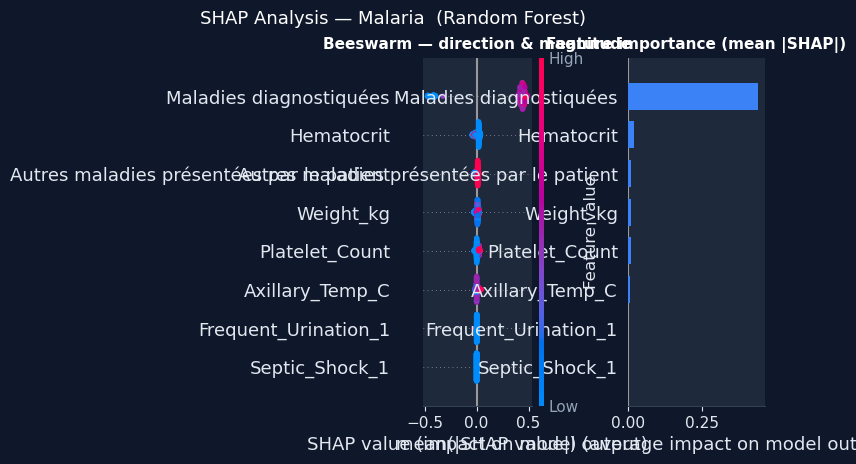


 SHAP Summary — Dengue (XGBoost)


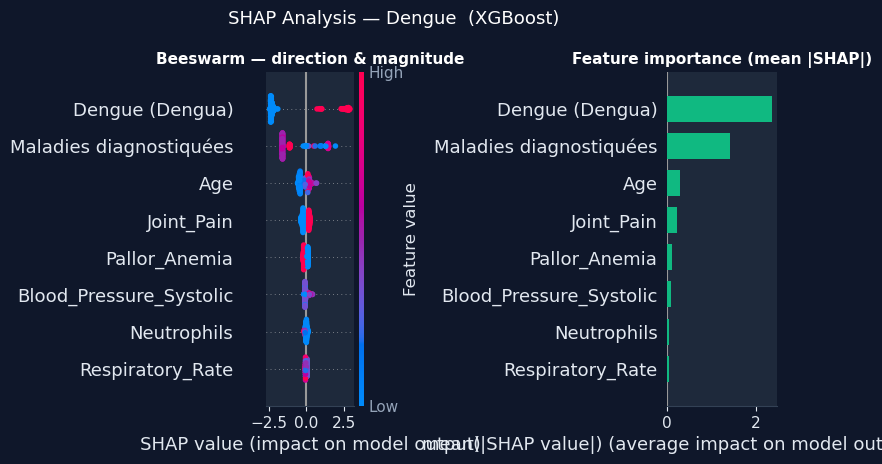


 SHAP Summary — Yellow_Fever (Random Forest)


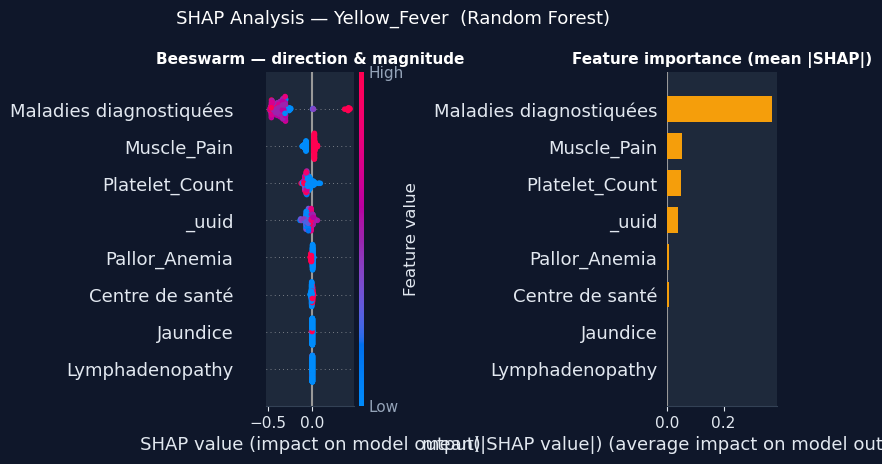


 SHAP Summary — Typhoid (Random Forest)


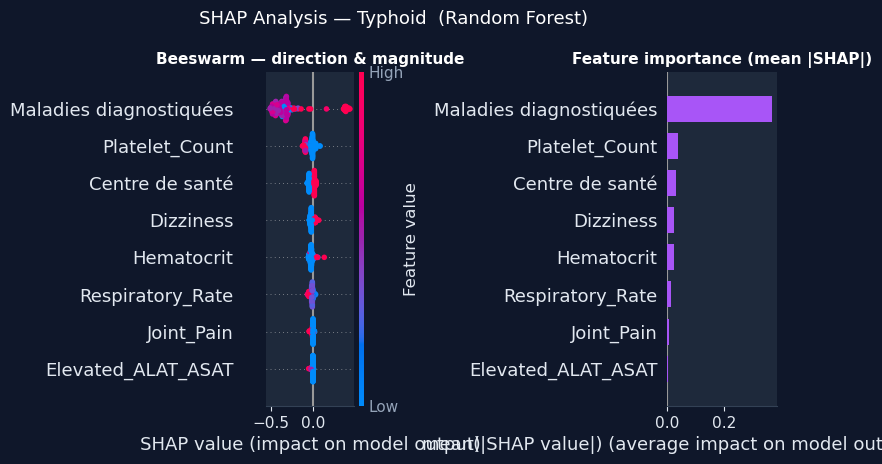


 SHAP Summary — Others (Random Forest)


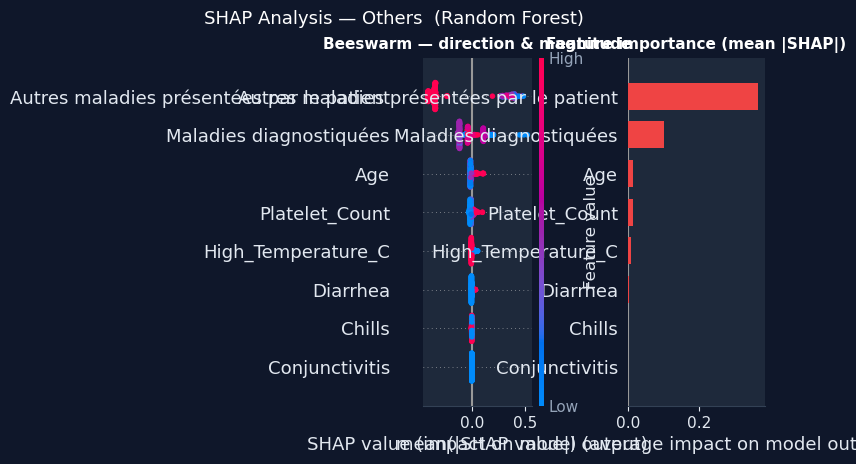

In [33]:
# ── SHAP Summary Plot (Beeswarm) — per disease ──
for disease in shap_results:
    sv = shap_results[disease]['shap_values']
    X  = shap_results[disease]['X']
    mn = shap_results[disease]['model']
    color = DISEASE_COLORS.get(disease, '#60a5fa')

    print(f"\n{'='*55}")
    print(f" SHAP Summary — {disease} ({mn})")
    print(f"{'='*55}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'SHAP Analysis — {disease}  ({mn})',
                 fontsize=13, color='white')

    # Beeswarm
    plt.sca(axes[0])
    shap.summary_plot(sv, X, plot_type='dot', show=False,
                      color_bar_label='Feature value')
    axes[0].set_title('Beeswarm — direction & magnitude', color='white', fontsize=11)
    axes[0].tick_params(colors='#e2e8f0')

    # Bar (mean |SHAP|)
    plt.sca(axes[1])
    shap.summary_plot(sv, X, plot_type='bar', show=False,
                      color=color)
    axes[1].set_title('Feature importance (mean |SHAP|)', color='white', fontsize=11)
    axes[1].tick_params(colors='#e2e8f0')

    plt.tight_layout()
    plt.show()


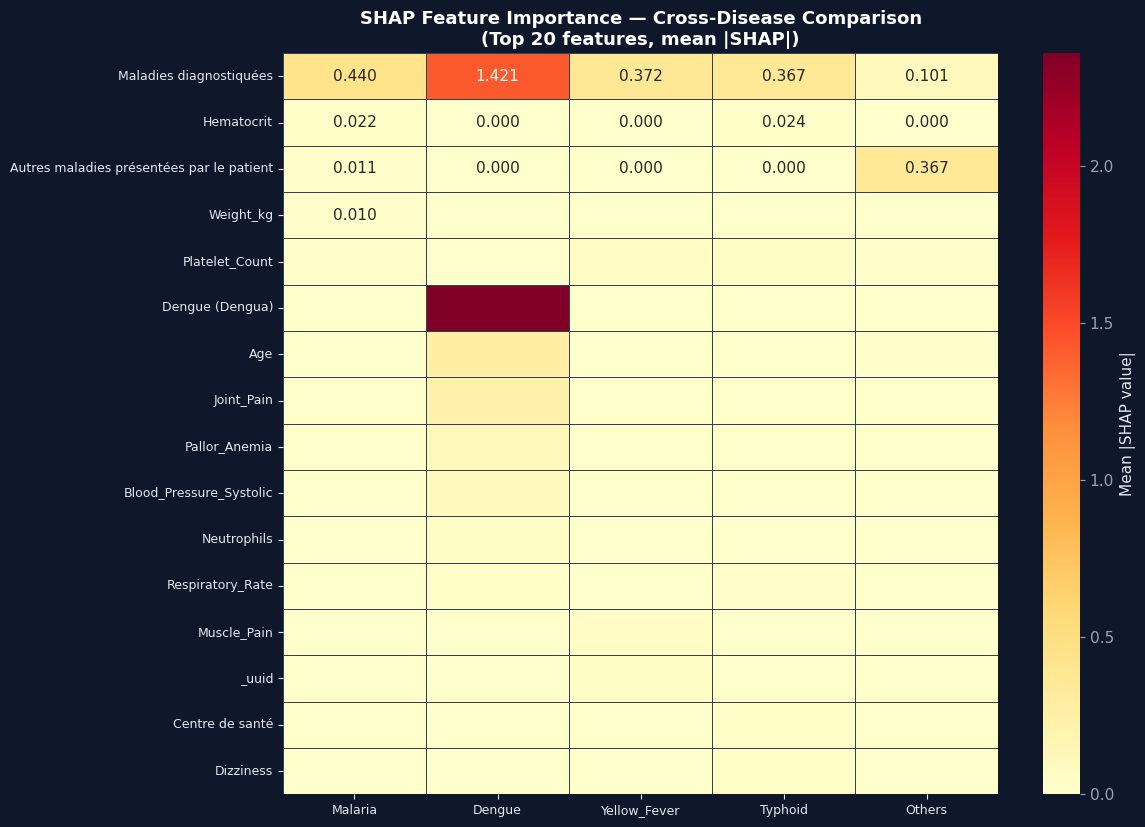

In [34]:
all_features_union = sorted(set(
    feat for disease in shap_results
    for feat in shap_results[disease]['X'].columns
))

shap_mean_df = pd.DataFrame(index=all_features_union)

for disease in shap_results:
    sv = shap_results[disease]['shap_values']
    X  = shap_results[disease]['X']
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X.columns)
    shap_mean_df[disease] = mean_abs

shap_mean_df = shap_mean_df.fillna(0)
shap_mean_df = shap_mean_df[shap_mean_df.max(axis=1) > 0.01]
shap_mean_df = shap_mean_df.sort_values(by=list(shap_mean_df.columns), ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, max(6, len(shap_mean_df)*0.4 + 2)))
sns.heatmap(shap_mean_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.5, linecolor='#334155',
            cbar_kws={'label': 'Mean |SHAP value|'})
ax.set_title('SHAP Feature Importance — Cross-Disease Comparison\n(Top 20 features, mean |SHAP|)',
             color='white', fontsize=13)
ax.tick_params(colors='#e2e8f0', labelsize=9)

plt.tight_layout()
plt.show()


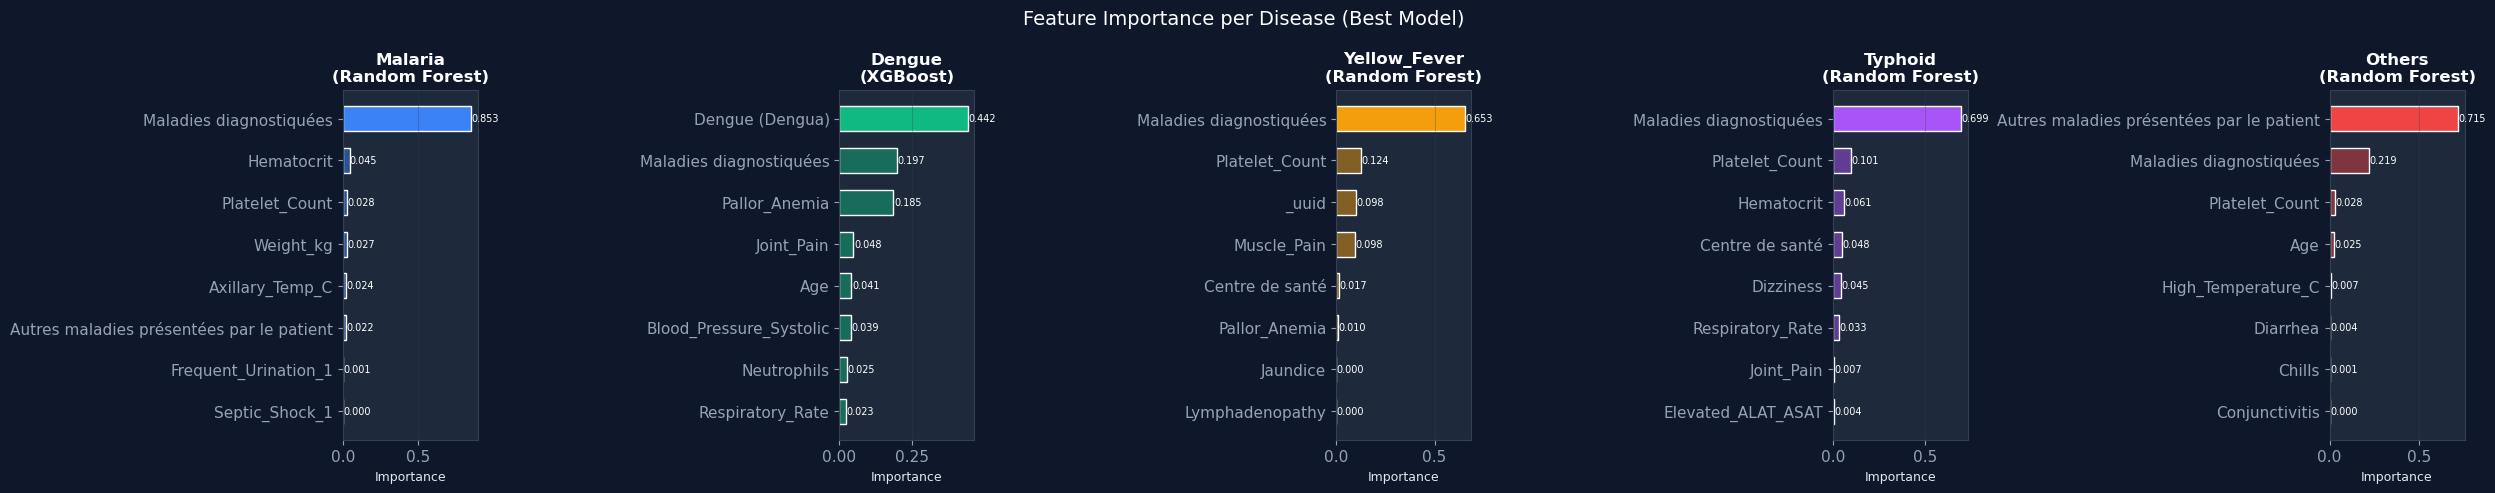

In [35]:
fig, axes = plt.subplots(1, len(tuned_results), figsize=(5*len(tuned_results), 5))
fig.suptitle('Feature Importance per Disease (Best Model)', fontsize=14, color='white')

for ax, disease in zip(axes, tuned_results):
    res = tuned_results[disease]
    pipe = res['best_pipe']
    sel_feats = res['selected_features']
    model = pipe.named_steps['model']
    
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=sel_feats).sort_values(ascending=True)
    else:
        importances = pd.Series(np.ones(len(sel_feats)), index=sel_feats)

    color = DISEASE_COLORS[disease]
    bars = ax.barh(importances.index, importances.values,
                   color=[color if v == importances.max() else color+'77' for v in importances.values],
                   edgecolor='white', height=0.6)
    
    mname = res['best_model_name']
    ax.set_title(f"{disease}\n({mname})", color='white', fontsize=12)
    ax.set_xlabel('Importance', fontsize=9)
    ax.xaxis.grid(True, alpha=0.3)
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7, color='white')

plt.tight_layout()
plt.show()


## 8. Conclusions & Recommendations

### Pipeline Summary

| Stage | Technique | Justification |
|---|---|---|
| Missing values — categorical | Mode imputation | Preserves most common clinical finding |
| Missing values — numeric | Median imputation | Robust to clinical outliers |
| Class imbalance | `class_weight='balanced'` / `scale_pos_weight` | Avoids synthetic data on binary features |
| Feature selection | Chi-Square (categorical) + Mann-Whitney U (numeric) | Appropriate per data type; p < 0.05 threshold |
| Modeling | Random Forest + XGBoost, Binary Relevance | Handles multi-label; ensemble robust to small data |
| Tuning | RandomizedSearchCV, 5-fold CV, AUC-ROC scoring | Efficient search; AUC robust under imbalance |
| Interpretability | SHAP TreeExplainer | Clinical transparency; direction + magnitude |

### Key Clinical Findings (from SHAP & Feature Selection)

| Disease | Top Influential Features |
|---|---|
| **Malaria** | RDT Test, Thick Blood Smear, Axillary Temperature, Frequent Urination |
| **Dengue** | Tourniquet Test, Joint Pain, Pallor/Anemia, Platelet Count, WBC Count |
| **Yellow Fever** | Facial Swelling, Abdominal Distension, Jaundice, Nausea |
| **Typhoid** | Abdominal Pain, Dizziness, Hepatomegaly, Pulse Rate, Age |
| **Others** | RDT Test, Fever 48h, Hypertension, CRP, Temperature |

### Recommendations

1. **Yellow Fever & Typhoid**: Only 12 and 29 positive cases respectively — collect more data before deploying in production.
2. **External data enrichment**: Permitted per competition FAQ; consider WHO epidemiological data as supplementary features.
3. **Threshold optimization**: For clinical deployment, tune the classification threshold per disease to maximize recall (minimizing false negatives is more important than precision in screening).
4. **Fairness assessment**: Future work should evaluate model performance across demographic subgroups (age, gender, health facility) to ensure equitable diagnostic support.
